### Open Field Ephys QC and Summary

1) Treats "mouse_name" as MouseID and builds a per-mouse summary table with counts and mean/median metrics.
2) Displays the first 5 rows and the per-mouse summary.
3) Plots mean_firing_rate distributions by mouse (boxplot).
4) Plots spatial_info vs coherence, with points grouped and colored by mouse, and legend outside.



Load the open_field.xlsx data into a DataFrame, cache it as Parquet, reload it, and preview basic info (head/shape/columns).
Perform data quality checks on df (trim column names, missing values, duplicates, outliers, type consistency, and categorical value consistency).

"""
- Load data from Excel- Convert to Parquet for faster loading
- Basic QC checks on the dataframe structure and content
  - Check for leading/trailing whitespace in column names
  - Count missing values per column
  - Count duplicate rows
  - Identify outliers in numeric columns (using IQR method)
  - Check for inconsistent data types within columns
  - List unique values in categorical columns
- Basic sanity checks on the data content
    - Distribution of mean firing rates across cells and mice
    - Relationship between spatial information and coherence
    - Per-mouse summary statistics (number of cells, mean firing rate, etc.)
- Violin plots with overlaid points (one colour per mouse, using tab20b)
    - Mean and median lines styled differently from default (e.g. mean in green, median in black)
    - Legend for mean/median line styles (not from tab20/tab20b)
    - Points use tab20b, one colour per mouse
- Statistical comparisons between experimenters (Mann–Whitney U test)
    - Only if there are exactly 2 experimenters and at least 3 samples per group
    - Annotate plots with p-values and significance stars
    - Include summary statistics (n, mean, median) in the annotation
"""


In [1]:
import re
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime as dt
import re, math, textwrap
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.lines import Line2D
from pathlib import Path

# Optional: nice dataframe display in notebooks (falls back to print)
try:
    from IPython.display import display  # type: ignore
    def display_df(title, x):
        print(title)
        display(x)
except Exception:
    def display_df(title, x):
        print(title)
        print(x)

In [2]:
# Set the input path ONCE (edit this one line only)
OPEN_FIELD_CSV_PATH = Path('/Users/loukia/Library/CloudStorage/Dropbox-UCL/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/Analysis/OF_concat/concatenated_trials.csv')
OPEN_FIELD_DIR = OPEN_FIELD_CSV_PATH.parent
# OPEN_FIELD_OUTDIR = OPEN_FIELD_DIR.parent / "OpenField_QC_outputs"
# (or, if you want it INSIDE the same folder as the excel:)
OPEN_FIELD_OUTDIR = OPEN_FIELD_DIR / "OpenField_QC_outputs"

OPEN_FIELD_OUTDIR.mkdir(parents=True, exist_ok=True)
print("Saving outputs to:", OPEN_FIELD_OUTDIR)

df_open_field = pd.read_csv(OPEN_FIELD_CSV_PATH) #select all cells in all trials

# Keep only openfield trials
df_open_field = df_open_field.loc[
    df_open_field["environment"].astype(str).str.contains("open.?field", case=False, na=False)
].copy()

# check if parket file exists and is up to date, otherwise save to parquet for faster loading next time

PARQUET_PATH = os.path.join(OPEN_FIELD_OUTDIR, "open_field.parquet")
df_open_field.to_parquet(PARQUET_PATH, index=False)
df_open_field = pd.read_parquet(PARQUET_PATH)

print(df_open_field["environment"].value_counts(dropna=False).head(10))
df_open_field.shape, df_open_field.columns.tolist()[:5], df_open_field.head()



Saving outputs to: /Users/loukia/Library/CloudStorage/Dropbox-UCL/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/Analysis/OF_concat/OpenField_QC_outputs
environment
open_field    1078
Name: count, dtype: int64


((1078, 36),
 ['filename', 'channel', 'cluster', 'num_spikes', 'mouse_name'],
                                             filename  channel  cluster  \
 0  /home/robin/Documents/Science/SWC/jok_loukia_r...        7       28   
 1  /home/robin/Documents/Science/SWC/jok_loukia_r...        7       27   
 2  /home/robin/Documents/Science/SWC/jok_loukia_r...        7       26   
 3  /home/robin/Documents/Science/SWC/jok_loukia_r...        7       25   
 4  /home/robin/Documents/Science/SWC/jok_loukia_r...        7       23   
 
    num_spikes  mouse_name Experimenter  Age_weeks Genotype  spike_width  \
 0      2438.0     1116810       Loukia       76.9     NLGF   489.795918   
 1       829.0     1116810       Loukia       76.9     NLGF   142.857143   
 2       618.0     1116810       Loukia       76.9     NLGF   346.938776   
 3       934.0     1116810       Loukia       76.9     NLGF   489.795918   
 4      1010.0     1116810       Loukia       76.9     NLGF   285.714286   
 
      Cell t

In [3]:
# df_open_field = pd.read_excel(os.path.join(OPEN_FIELD_DIR, "open_field.xlsx"))

def _find_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    raise KeyError(f"None of these columns found: {candidates}\nAvailable: {list(df.columns)}")

celltype_col = _find_col(df_open_field, ["cell_type", "Cell type", "Cell Type"])
genotype_col  = _find_col(df_open_field, ["Phenotype", "genotype", "Genotype", "geno", "genotype_group", "Genotype group"])
trial_col     = _find_col(df_open_field, ["trial_type", "trial", "environment"])

df_tmp = df_open_field.copy()

# clean "['openfieldb']" -> "openfieldb"
df_tmp["trial_type_clean"] = (
    df_tmp[trial_col]
    .astype(str)
    .str.replace(r"[\[\]']", "", regex=True)
    .str.strip()
)

# counts: (trial, genotype, cell_type) -> n
counts_by_trial_geno_celltype = (
    df_tmp
    .groupby(["trial_type_clean", genotype_col, celltype_col], dropna=False)
    .size()
    .rename("n")
    .reset_index()
)

# wide table: rows = (trial, genotype), columns = cell types, values = counts
table = (
    counts_by_trial_geno_celltype
    .pivot_table(
        index=["trial_type_clean", genotype_col],
        columns=celltype_col,
        values="n",
        fill_value=0,
        aggfunc="sum",
    )
    .sort_index()
)

print("Cell type counts by trial and genotype:")
display(table)

Cell type counts by trial and genotype:


Cell type                  Interneuron  Pyramidal
trial_type_clean Genotype                        
open_field       NLGF              205        316
                 WT                142        415

In [4]:
"""Basic QC checks on the dataframe structure and content
- Check for leading/trailing whitespace in column names
- Count missing values per column
- Count duplicate rows
- Identify outliers in numeric columns (using IQR method)
- Check for inconsistent data types within columns
- List unique values in categorical columns
"""

# Remove leading/trailing whitespace from column names
df_open_field.columns = df_open_field.columns.str.strip()

# Missing values per column
missing_values = df_open_field.isnull().sum()
print("Missing values in each column:")
print(missing_values)

# Duplicate rows
duplicate_rows = df_open_field.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_rows}")

# Outliers in numeric columns via IQR
numerical_cols = df_open_field.select_dtypes(include=[np.number]).columns
for col in numerical_cols:
    Q1 = df_open_field[col].quantile(0.25)
    Q3 = df_open_field[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df_open_field[(df_open_field[col] < lower_bound) | (df_open_field[col] > upper_bound)]
    print(f"Column: {col}, Number of outliers: {len(outliers)}")

# Inconsistent types per column (can be slow on very large dataframes)
for col in df_open_field.columns:
    data_types = df_open_field[col].apply(type).value_counts()
    print(f"Column: {col}, Data types:\n{data_types}\n")

# Unique values in categorical columns
categorical_cols = df_open_field.select_dtypes(include=["object"]).columns
for col in categorical_cols:
    unique_values = df_open_field[col].unique()
    print(f"Column: {col}, Unique values:\n{unique_values}\n")

Missing values in each column:
filename                            0
channel                             0
cluster                             0
num_spikes                          0
mouse_name                          0
Experimenter                        0
Age_weeks                           0
Genotype                            0
spike_width                         0
Cell type                           0
theta_mod_v1                        0
theta_mod_v2                       20
theta_mod_v3                        0
peak_rate                           0
mean_rate                           0
ahp_decay                         130
field_size                          0
phase_mean                          0
phase_variance                      0
overdispersion                      0
spatial_info                        0
coherence                           0
phase_locking_vector_length         0
phase_locking_z_stat                0
phase_locking_pval                  0
head_dir_mean_resul

/var/folders/7r/v13tprj17p5fvy167bbhtmch0000gn/T/ipykernel_22681/337243538.py:39: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df_open_field.select_dtypes(include=["object"]).columns


Per-mouse summary


,mouse_name,n_cells,n_tetrodes,mean_mean_firing_rate,median_mean_firing_rate,mean_spatial_info,mean_coherence,mean_field_size,mean_theta_modulation
14,1118467,140,8,1.545198,0.831377,0.274678,0.470469,673.601565,0.060847
8,1116808,111,8,1.254848,0.398834,0.169066,0.284318,730.082118,0.053400
9,1116810,94,7,0.803524,0.361782,0.129756,0.118140,764.981813,0.016719
13,1118466,83,8,2.571402,1.015730,0.323800,0.425916,682.034904,0.046059
15,1118468,68,8,1.888974,0.676726,0.600753,0.512061,550.592354,0.096879
6,733075,66,8,3.276084,0.674797,0.107286,0.096208,645.222303,0.019123
16,1118674,66,7,1.820311,0.695396,0.584979,0.337976,558.639921,0.086773
7,1116806,57,8,1.977855,0.583680,0.238503,0.435728,701.021115,0.047536
4,726050,57,8,1.407598,0.786696,0.170976,0.181126,625.320152,0.024675
12,1117537,51,6,1.836533,0.726196,0.500911,0.364473,652.985294,0.074833


Summary saved to: /Users/loukia/Library/CloudStorage/Dropbox-UCL/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/Analysis/OF_concat/OpenField_QC_outputs/1.open_field_summary.csv
-----------------------------------------------------------------------------------------------------------------------------------------------
Open field data (first 100 rows)


,filename,channel,cluster,num_spikes,mouse_name,Experimenter,Age_weeks,Genotype,spike_width,Cell type,...,head_dir_mean_resultant_angle,contamination_Q,contamination_R,head_dir_kl_div,kl_spatial_sparsity,spatial_sparsity,environment,half_split_stability,odd_even_stability,theta_phase_label
0,/home/robin/Documents/Science/SWC/jok_loukia_r...,7,28,2438.0,1116810,Loukia,76.9,NLGF,489.795918,Pyramidal,...,2.881674,0.11976,0.000064,0.017561,0.533207,0.961626,open_field,0.611469,0.720919,Peak
1,/home/robin/Documents/Science/SWC/jok_loukia_r...,7,27,829.0,1116810,Loukia,76.9,NLGF,142.857143,Interneuron,...,3.236768,0.00000,0.127398,0.020096,0.533207,0.983011,open_field,0.299243,0.527620,Middle
2,/home/robin/Documents/Science/SWC/jok_loukia_r...,7,26,618.0,1116810,Loukia,76.9,NLGF,346.938776,Pyramidal,...,0.878663,0.00000,0.139625,0.033001,0.533207,0.971124,open_field,0.357244,0.591473,Middle
3,/home/robin/Documents/Science/SWC/jok_loukia_r...,7,25,934.0,1116810,Loukia,76.9,NLGF,489.795918,Pyramidal,...,3.308153,0.00000,0.124848,0.020773,0.533207,0.924774,open_field,0.465514,0.846983,Middle
4,/home/robin/Documents/Science/SWC/jok_loukia_r...,7,23,1010.0,1116810,Loukia,76.9,NLGF,285.714286,Interneuron,...,1.721044,0.00000,0.004622,0.032574,0.533207,0.917997,open_field,0.166132,0.760536,Middle
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,/home/robin/Documents/Science/SWC/jok_loukia_r...,2,23,861.0,1118466,Loukia,71.3,WT,142.857143,Interneuron,...,4.924659,0.00000,0.101740,0.031898,0.429713,0.970465,open_field,0.575084,0.686360,Middle
96,/home/robin/Documents/Science/SWC/jok_loukia_r...,3,20,110.0,1118466,Loukia,71.3,WT,224.489796,Interneuron,...,1.529551,0.00000,0.424906,0.181240,0.429713,0.912993,open_field,0.128547,0.183228,Middle
97,/home/robin/Documents/Science/SWC/jok_loukia_r...,2,20,212.0,1118466,Loukia,71.3,WT,183.673469,Interneuron,...,3.450973,0.00000,0.251167,0.092095,0.429713,0.914846,open_field,0.353546,0.385309,Middle
98,/home/robin/Documents/Science/SWC/jok_loukia_r...,2,19,218.0,1118466,Loukia,71.3,WT,183.673469,Interneuron,...,6.087149,0.00000,0.284992,0.102894,0.429713,0.936677,open_field,0.222500,0.344825,Middle


<Figure size 640x480 with 0 Axes>

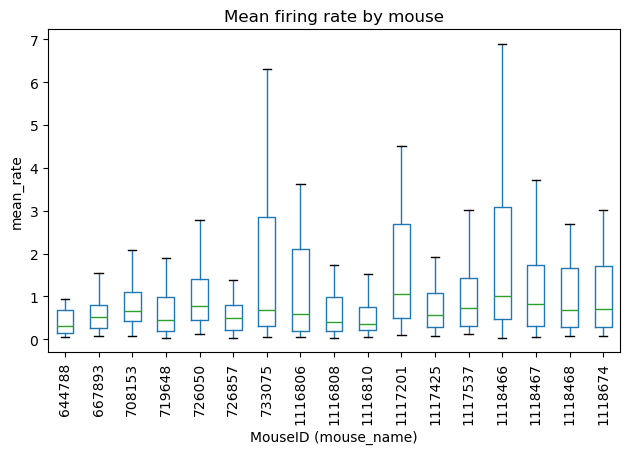

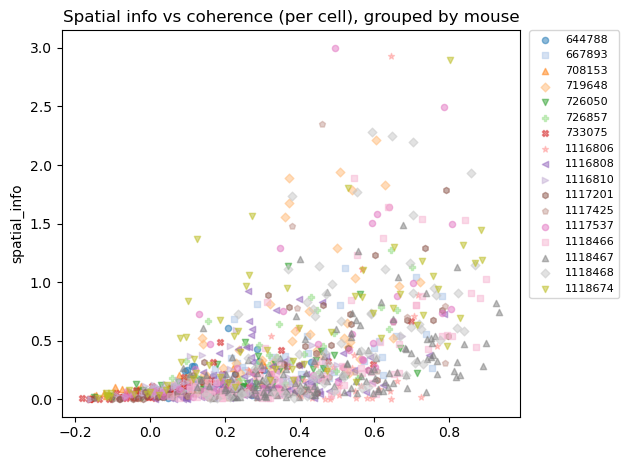

In [5]:
"""Basic sanity checks on the data content
- Distribution of mean firing rates across cells and mice
- Relationship between spatial information and coherence
- Per-mouse summary statistics (number of cells, mean firing rate, etc.)
"""

# Treat mouse_name as MouseID
mouse_col = "mouse_name"
mice = sorted(df_open_field[mouse_col].dropna().unique().tolist())

# Per-mouse summary
summary = (df_open_field.groupby(mouse_col)
             .agg(
                 n_cells=("cluster","count"),
                 n_tetrodes=("channel","nunique"),
                 mean_mean_firing_rate=("mean_rate","mean"),
                 median_mean_firing_rate=("mean_rate","median"),
                 mean_spatial_info=("spatial_info","mean"),
                 mean_coherence=("coherence","mean"),
                 mean_field_size=("field_size","mean"),
                 mean_theta_modulation=("theta_mod_v3","mean"),
             )
             .reset_index()
             .sort_values("n_cells", ascending=False))

display_df("Per-mouse summary", summary)
save_path = os.path.join(OPEN_FIELD_OUTDIR, "1.open_field_summary.csv")
summary.to_csv(save_path, index=False)
print(f"Summary saved to: {save_path}")
print("-----------------------------------------------------------------------------------------------------------------------------------------------")                    
display_df("Open field data (first 100 rows)", df_open_field.head(100))


# Plot 1: distribution of mean firing rate per mouse
plt.figure()
df_open_field.boxplot(column="mean_rate", by=mouse_col, grid=False, rot=90, showfliers=False)
plt.title("Mean firing rate by mouse")
plt.suptitle("")
plt.xlabel("MouseID (mouse_name)")
plt.ylabel("mean_rate")
plt.tight_layout()
plt.savefig(os.path.join(OPEN_FIELD_OUTDIR, "1.mean_firing_rate_boxplot_by_mouse.png"), dpi=300, bbox_inches="tight")   
plt.show()

# Plot 2: spatial_info vs coherence (per cell), grouped by mouse with color + marker
plt.figure()

markers = ["o", "s", "^", "D", "v", "P", "X", "*", "<", ">", "h", "p"]
cmap = plt.get_cmap("tab20")  # 20 distinct colors, then repeats

for i, m in enumerate(mice):
    g = df_open_field.loc[df_open_field[mouse_col] == m]
    plt.scatter(
        g["coherence"],
        g["spatial_info"],
        label=str(m),
        alpha=0.5,
        s=20,
        marker=markers[i % len(markers)],
        color=cmap(i % 20),
    )

plt.title("Spatial info vs coherence (per cell), grouped by mouse")
plt.xlabel("coherence")
plt.ylabel("spatial_info")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0, fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(OPEN_FIELD_OUTDIR, "1.spatial_info_vs_coherence_by_mouse.png"), dpi=300, bbox_inches="tight")
plt.show()

### Generate boxplots with overlaid points for all numeric columns, grouped by mouse.
#### Create a multi-page PDF with one plot per numeric column showing distributions across mice.

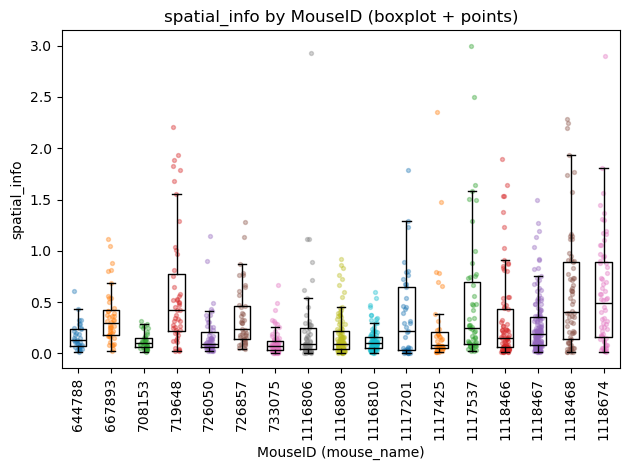

'/Users/loukia/Library/CloudStorage/Dropbox-UCL/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/Analysis/OF_concat/OpenField_QC_outputs/2.open_field_all_numeric_boxplots_with_points_by_mouse.pdf'

In [6]:
mouse_col = "mouse_name"
mice = sorted(df_open_field[mouse_col].dropna().unique().tolist())
numeric_cols = [c for c in df_open_field.select_dtypes(include=[np.number]).columns if c != mouse_col]

rng = np.random.default_rng(0)

def boxplot_with_points(ax, data, col, mice, jitter=0.12, point_size=8, alpha=0.35, showfliers=False):
    groups = []
    labels = []

    for m in mice:
        vals = data.loc[data[mouse_col] == m, col].dropna().values
        groups.append(vals)
        labels.append(str(m))

    ax.boxplot(
    groups,
    showfliers=showfliers,
    medianprops=dict(color="black", linewidth=1),
)

    # overlay points (jittered)
    for i, vals in enumerate(groups, start=1):
        if len(vals) == 0:
            continue
        x = i + rng.uniform(-jitter, jitter, size=len(vals))
        ax.scatter(x, vals, s=point_size, alpha=alpha)

    ax.set_xticks(range(1, len(labels) + 1))
    ax.set_xticklabels(labels, rotation=90)
    ax.set_xlabel("MouseID (mouse_name)")
    ax.set_ylabel(col)
    ax.set_title(f"{col} by MouseID (boxplot + points)")

# Example plot for spatial_info
plt.figure()
ax = plt.gca()
boxplot_with_points(ax, df_open_field, "spatial_info", mice)
plt.tight_layout()
plt.show()

# Multi-page PDF (save next to the Excel file)
pdf_path = os.path.join(
    OPEN_FIELD_OUTDIR,
    "2.open_field_all_numeric_boxplots_with_points_by_mouse.pdf"
)

with PdfPages(pdf_path) as pdf:
    fig = plt.figure(figsize=(11.69, 8.27))
    txt = (
        "Open field dataset\n"
        f"Rows: {len(df_open_field):,} | Columns: {df_open_field.shape[1]:,}\n"
        f"MouseID column: {mouse_col}\n"
        "Contents: one boxplot per numeric column, grouped by MouseID,\n"
        "with individual observations overlaid (jittered points).\n"
    )
    fig.text(0.05, 0.9, txt, fontsize=16, va="top")
    plt.axis("off")
    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

    for col in numeric_cols:
        fig = plt.figure(figsize=(11.69, 8.27))
        ax = fig.add_subplot(111)
        boxplot_with_points(ax, df_open_field, col, mice, jitter=0.12, point_size=6, alpha=0.4, showfliers=False)
        fig.tight_layout()
        pdf.savefig(fig)
        plt.close(fig)

pdf_path

### Generate violin plots with overlaid points for all numeric columns, grouped by mouse.
#### Create a multi-page PDF with one plot per numeric column showing distributions across mice.

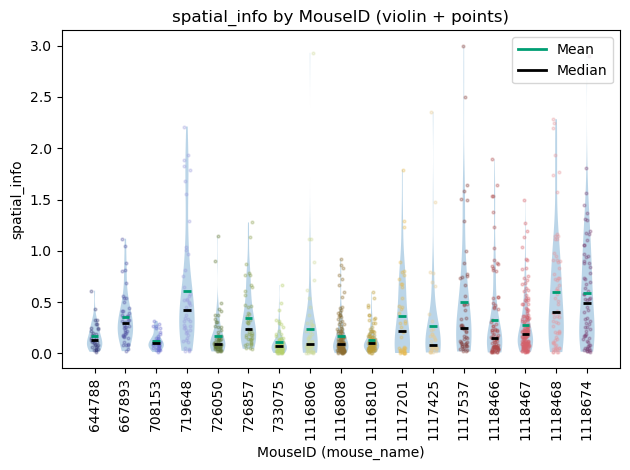

PDF saved to: /Users/loukia/Library/CloudStorage/Dropbox-UCL/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/Analysis/OF_concat/OpenField_QC_outputs/3.open_field_all_numeric_violinplots_with_points_by_mouse.pdf


'/Users/loukia/Library/CloudStorage/Dropbox-UCL/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/Analysis/OF_concat/OpenField_QC_outputs/3.open_field_all_numeric_violinplots_with_points_by_mouse.pdf'

In [7]:
"""Violin plots with overlaid points (one colour per mouse, using tab20b)
- Mean and median lines styled differently from default (e.g. mean in green, median in black)
- Legend for mean/median line styles (not from tab20/tab20b)
- Points use tab20b, one colour per mouse
"""

mouse_col = "mouse_name"
mice = sorted(df_open_field[mouse_col].dropna().unique().tolist())
numeric_cols = [c for c in df_open_field.select_dtypes(include=[np.number]).columns if c != mouse_col]

rng = np.random.default_rng(0)
point_cmap = plt.get_cmap("tab20b")  # <- use tab20b everywhere for points

# Mean/median legend (NOT from tab20/tab20b)
legend_elements = [
    Line2D([0], [0], color="#009E73", lw=2, linestyle="-", label="Mean"),
    Line2D([0], [0], color="black", lw=2, linestyle="-", label="Median"),
]

def violin_with_points(ax, data, col, mice, jitter=0.12, point_size=4, alpha=0.3):
    groups = []
    labels = []
    for m in mice:
        vals = data.loc[data[mouse_col] == m, col].dropna().values
        groups.append(vals)
        labels.append(str(m))

    parts = ax.violinplot(
        groups,
        showmeans=True,
        showmedians=True,
        showextrema=False,
    )

    # Mean / median styling
    if parts.get("cmeans") is not None:
        parts["cmeans"].set_color("#009E73")
        parts["cmeans"].set_linewidth(2)
        parts["cmeans"].set_linestyle("-")

    if parts.get("cmedians") is not None:
        parts["cmedians"].set_color("black")
        parts["cmedians"].set_linewidth(2)
        parts["cmedians"].set_linestyle("-")

    # Overlay points (jittered) — tab20b, one colour per mouse
    for i, vals in enumerate(groups, start=1):
        if len(vals) == 0:
            continue
        x = i + rng.uniform(-jitter, jitter, size=len(vals))
        ax.scatter(
            x,
            vals,
            s=point_size,
            alpha=alpha,
            color=point_cmap((i - 1) % 20),
        )

    ax.set_xticks(range(1, len(labels) + 1))
    ax.set_xticklabels(labels, rotation=90)
    ax.set_xlabel("MouseID (mouse_name)")
    ax.set_ylabel(col)
    ax.set_title(f"{col} by MouseID (violin + points)")
    ax.legend(handles=legend_elements, loc="upper right")


# Example plot
plt.figure()
ax = plt.gca()
violin_with_points(ax, df_open_field, "spatial_info", mice)
plt.tight_layout()
plt.show()

# Multi-page PDF (PDF uses the function; no extra legend call needed)
savepdf_path = os.path.join(
    OPEN_FIELD_OUTDIR,
    "3.open_field_all_numeric_violinplots_with_points_by_mouse.pdf",
)
print(f"PDF saved to: {savepdf_path}")

with PdfPages(savepdf_path) as pdf:
    fig = plt.figure(figsize=(11.69, 8.27))
    txt = (
        "Open field dataset\n"
        f"Rows: {len(df_open_field):,} | Columns: {df_open_field.shape[1]:,}\n"
        f"MouseID column: {mouse_col}\n"
        "Contents: one violin plot per numeric column, grouped by MouseID,\n"
        "with individual observations overlaid (jittered points).\n"
        "Points use tab20b.\n"
    )
    fig.text(0.05, 0.9, txt, fontsize=16, va="top")
    plt.axis("off")
    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

    for col in numeric_cols:
        fig = plt.figure(figsize=(11.69, 8.27))
        ax = fig.add_subplot(111)
        violin_with_points(ax, df_open_field, col, mice)
        fig.tight_layout()
        pdf.savefig(fig)
        plt.close(fig)

savepdf_path

# The following cells are assuming normal distribution and are using Linear Mixed Model (LMM) to test for effects of Experimenter and Age_weeks 
Recommendation: Keep the QC notebook for steps 1–2 (QC and plots). For the actual statistical conclusion about which metrics need Experimenter/Age covariates, rely on confound_testing_glmm.ipynb. You could add a note in the QC notebook's confound cells that these have been superseded.. Instead, proceed to check using script confound_testing_glmm.ipynb

In [ ]:
"""Linear Mixed Model (LMM) to test for effects of Experimenter and Age_weeks on numeric columns
- Model: y ~ Experimenter * Age_weeks + (1|mouse_name)
- Uses statsmodels MixedLM (no R dependency)
- Extract p-values for Experimenter, Age_weeks, and their interaction
"""

import warnings
warnings.filterwarnings('ignore')

import statsmodels.formula.api as smf

def _sig(p):
    if not np.isfinite(p): return 'NA'
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'ns'

lmm_results = []

for col in numeric_cols:
    if col in ['tetrode', 'cluster', 'mouse_name', 'Age_weeks', 'Experimenter']:
        continue

    test_data = df_open_field[[col, 'Experimenter', 'Age_weeks', 'mouse_name']].dropna()

    if len(test_data) < 10:
        continue
    if test_data['mouse_name'].nunique() < 2:
        continue

    try:
        # Standardize Age_weeks for model stability
        test_data = test_data.copy()
        test_data['Age_weeks_z'] = (test_data['Age_weeks'] - test_data['Age_weeks'].mean()) / test_data['Age_weeks'].std()

        # Sanitize column name for formula
        test_data = test_data.rename(columns={col: 'y_response'})

        md = smf.mixedlm(
            "y_response ~ C(Experimenter) * Age_weeks_z",
            data=test_data,
            groups=test_data["mouse_name"]
        )
        mdf = md.fit(reml=True)

        # Extract p-values from fixed effects
        pvals = mdf.pvalues
        p_exp = float(pvals.get('C(Experimenter)[T.Ruth]',
                      pvals.get('C(Experimenter)[T.Loukia]', np.nan)))
        p_age = float(pvals.get('Age_weeks_z', np.nan))

        # Interaction term name depends on reference level
        int_keys = [k for k in pvals.index if 'Experimenter' in k and 'Age_weeks_z' in k]
        p_int = float(pvals[int_keys[0]]) if int_keys else np.nan

        lmm_results.append({
            'column': col,
            'n_observations': len(test_data),
            'n_mice': test_data['mouse_name'].nunique(),
            'p_Experimenter': p_exp,
            'p_Age_weeks': p_age,
            'p_Interaction': p_int,
            'sig_Experimenter': _sig(p_exp),
            'sig_Age_weeks': _sig(p_age),
            'sig_Interaction': _sig(p_int),
        })
    except Exception as e:
        print(f"Could not run LMM for {col}: {e}")
        continue

df_lmm_results = pd.DataFrame(lmm_results)

display_df("LMM Results: Experimenter + Age_weeks + Interaction, random intercept = mouse_name", df_lmm_results)

lmm_save_path = os.path.join(OPEN_FIELD_OUTDIR, "4.open_field_lmm_experimenter_age.csv")
df_lmm_results.to_csv(lmm_save_path, index=False)
print(f"\nLMM results saved to: {lmm_save_path}")

print("\n=== SUMMARY OF SIGNIFICANT EFFECTS (p < 0.05) ===")
if len(df_lmm_results) > 0:
    print(f"\nExperimenter effects: {(df_lmm_results['sig_Experimenter'].isin(['*','**','***'])).sum()} out of {len(df_lmm_results)} columns")
    print(f"Age_weeks effects: {(df_lmm_results['sig_Age_weeks'].isin(['*','**','***'])).sum()} out of {len(df_lmm_results)} columns")
    print(f"Interaction effects: {(df_lmm_results['sig_Interaction'].isin(['*','**','***'])).sum()} out of {len(df_lmm_results)} columns")
else:
    print("No results — check errors above.")

/Users/loukia/miniconda3/envs/scripts313/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/Users/loukia/miniconda3/envs/scripts313/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/Users/loukia/miniconda3/envs/scripts313/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/Users/loukia/miniconda3/envs/scripts313/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/loukia/miniconda3/envs/scripts

LMM Results: Experimenter + Age_weeks + Interaction, random intercept = mouse_name


/Users/loukia/miniconda3/envs/scripts313/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/Users/loukia/miniconda3/envs/scripts313/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


,column,n_observations,n_mice,p_Experimenter,p_Age_weeks,p_Interaction,sig_Experimenter,sig_Age_weeks,sig_Interaction
0,channel,1078,17,9.496367e-01,0.650742,0.665535,ns,ns,ns
1,num_spikes,1078,17,6.275894e-02,0.810688,0.369845,ns,ns,ns
2,spike_width,1078,17,6.442616e-01,0.645218,0.374998,ns,ns,ns
3,theta_mod_v1,1078,17,9.543690e-01,0.728299,0.029049,ns,ns,*
4,theta_mod_v2,1058,17,9.343539e-02,0.680232,0.921734,ns,ns,ns
5,theta_mod_v3,1078,17,7.515169e-01,0.265991,0.295186,ns,ns,ns
6,peak_rate,1078,17,4.832937e-02,0.194140,0.792230,*,ns,ns
7,mean_rate,1078,17,1.281834e-01,0.572636,0.577147,ns,ns,ns
8,ahp_decay,948,17,5.191267e-02,0.499331,0.653808,ns,ns,ns
9,field_size,1078,17,1.451874e-03,0.098506,0.019578,**,ns,*



LMM results saved to: /Users/loukia/Library/CloudStorage/Dropbox-UCL/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/Analysis/OF_concat/OpenField_QC_outputs/4.open_field_lmm_experimenter_age.csv

=== SUMMARY OF SIGNIFICANT EFFECTS (p < 0.05) ===

Experimenter effects: 6 out of 27 columns
Age_weeks effects: 1 out of 27 columns
Interaction effects: 6 out of 27 columns


In [ ]:
"""
Confound testing: Experimenter + Age_weeks effects on all metrics (pure Python)
──────────────────────────────────────────────────────────────────────────────
Three models per metric to disentangle correlated predictors:
  Model A: y ~ Experimenter            + (1|mouse_name)
  Model B: y ~ Age_weeks_z             + (1|mouse_name)
  Model C: y ~ Experimenter + Age_weeks_z + (1|mouse_name)
"""

import warnings
warnings.filterwarnings('ignore')
import statsmodels.formula.api as smf

def _sig(p):
    if not np.isfinite(p): return 'NA'
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'ns'

confound_results = []
skip_cols = {'tetrode', 'cluster', 'mouse_name', 'Age_weeks', 'Experimenter', 'Genotype',
             'Cell type', 'environment', 'trial_type'}

for col in numeric_cols:
    if col in skip_cols:
        continue

    sub = df_open_field[[col, 'Experimenter', 'Age_weeks', 'mouse_name']].dropna().copy()
    if len(sub) < 10 or sub['mouse_name'].nunique() < 3:
        continue

    sub['Age_weeks_z'] = (sub['Age_weeks'] - sub['Age_weeks'].mean()) / sub['Age_weeks'].std()
    sub = sub.rename(columns={col: 'y'})

    row = {'metric': col, 'n_obs': len(sub), 'n_animals': sub['mouse_name'].nunique()}

    # Model A: Experimenter only
    try:
        fitA = smf.mixedlm("y ~ C(Experimenter)", data=sub, groups=sub["mouse_name"]).fit(reml=True)
        exp_keys = [k for k in fitA.pvalues.index if 'Experimenter' in k]
        row['A_p_Experimenter'] = float(fitA.pvalues[exp_keys[0]]) if exp_keys else np.nan
    except:
        row['A_p_Experimenter'] = np.nan

    # Model B: Age only
    try:
        fitB = smf.mixedlm("y ~ Age_weeks_z", data=sub, groups=sub["mouse_name"]).fit(reml=True)
        row['B_p_Age'] = float(fitB.pvalues.get('Age_weeks_z', np.nan))
    except:
        row['B_p_Age'] = np.nan

    # Model C: Both
    try:
        fitC = smf.mixedlm("y ~ C(Experimenter) + Age_weeks_z", data=sub, groups=sub["mouse_name"]).fit(reml=True)
        exp_keys = [k for k in fitC.pvalues.index if 'Experimenter' in k]
        row['C_p_Experimenter'] = float(fitC.pvalues[exp_keys[0]]) if exp_keys else np.nan
        row['C_p_Age'] = float(fitC.pvalues.get('Age_weeks_z', np.nan))
    except:
        row['C_p_Experimenter'] = np.nan
        row['C_p_Age'] = np.nan

    row['A_sig'] = _sig(row['A_p_Experimenter'])
    row['B_sig'] = _sig(row['B_p_Age'])
    row['C_sig_Exp'] = _sig(row['C_p_Experimenter'])
    row['C_sig_Age'] = _sig(row['C_p_Age'])

    confound_results.append(row)
    print(f"  {col:40s} n={len(sub):<5d} Exp(A):{row['A_sig']}  Age(B):{row['B_sig']}  Exp(C):{row['C_sig_Exp']}  Age(C):{row['C_sig_Age']}")

df_confound = pd.DataFrame(confound_results)
display_df("Confound Testing: Experimenter vs Age (3 models per metric)", df_confound)

confound_path = os.path.join(OPEN_FIELD_OUTDIR, "4b.open_field_confound_testing.csv")
df_confound.to_csv(confound_path, index=False)
print(f"\nConfound results saved to: {confound_path}")

print("\n=== INTERPRETATION ===")
print("Model A = Experimenter only | Model B = Age only | Model C = both together")
print("If A & B significant but C makes both ns → collinearity masks effects")
print("If only one stays significant in C → that is the true driver")
if len(df_confound) > 0:
    print(f"\nMetrics with Experimenter significant in Model C: {(df_confound['C_sig_Exp'].isin(['*','**','***'])).sum()}")
    print(f"Metrics with Age significant in Model C: {(df_confound['C_sig_Age'].isin(['*','**','***'])).sum()}")

  channel                                  n=1078  Exp(A):ns  Age(B):ns  Exp(C):ns  Age(C):ns
  num_spikes                               n=1078  Exp(A):*  Age(B):ns  Exp(C):ns  Age(C):ns
  spike_width                              n=1078  Exp(A):ns  Age(B):ns  Exp(C):ns  Age(C):ns
  theta_mod_v1                             n=1078  Exp(A):***  Age(B):**  Exp(C):ns  Age(C):ns
  theta_mod_v2                             n=1058  Exp(A):**  Age(B):ns  Exp(C):*  Age(C):ns
  theta_mod_v3                             n=1078  Exp(A):ns  Age(B):ns  Exp(C):ns  Age(C):ns
  peak_rate                                n=1078  Exp(A):ns  Age(B):ns  Exp(C):*  Age(C):ns
  mean_rate                                n=1078  Exp(A):ns  Age(B):ns  Exp(C):ns  Age(C):ns
  ahp_decay                                n=948   Exp(A):***  Age(B):*  Exp(C):**  Age(C):ns
  field_size                               n=1078  Exp(A):ns  Age(B):ns  Exp(C):ns  Age(C):**
  phase_mean                               n=1078  Exp(A):ns  

,metric,n_obs,n_animals,A_p_Experimenter,B_p_Age,C_p_Experimenter,C_p_Age,A_sig,B_sig,C_sig_Exp,C_sig_Age
0,channel,1078,17,7.054797e-01,9.328237e-01,6.382113e-01,7.654932e-01,ns,ns,ns,ns
1,num_spikes,1078,17,1.457655e-02,1.012392e-01,8.801504e-02,8.427103e-01,*,ns,ns,ns
2,spike_width,1078,17,8.840343e-01,9.203414e-01,9.076422e-01,9.783633e-01,ns,ns,ns,ns
3,theta_mod_v1,1078,17,9.804470e-04,5.287258e-03,1.241964e-01,4.661079e-01,***,**,ns,ns
4,theta_mod_v2,1058,17,5.805206e-03,1.197653e-01,2.927730e-02,5.822778e-01,**,ns,*,ns
5,theta_mod_v3,1078,17,2.448989e-01,6.770181e-01,2.055272e-01,4.912777e-01,ns,ns,ns,ns
6,peak_rate,1078,17,8.920706e-02,7.751019e-01,1.477771e-02,9.344884e-02,ns,ns,*,ns
7,mean_rate,1078,17,2.044413e-01,7.279011e-01,1.193671e-01,3.360751e-01,ns,ns,ns,ns
8,ahp_decay,948,17,2.318968e-05,1.838013e-02,1.890199e-03,5.862927e-01,***,*,**,ns
9,field_size,1078,17,8.013498e-01,5.660635e-02,5.204405e-02,4.734508e-03,ns,ns,ns,**



Confound results saved to: /Users/loukia/Library/CloudStorage/Dropbox-UCL/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/Analysis/OF_concat/OpenField_QC_outputs/4b.open_field_confound_testing.csv

=== INTERPRETATION ===
Model A = Experimenter only | Model B = Age only | Model C = both together
If A & B significant but C makes both ns → collinearity masks effects
If only one stays significant in C → that is the true driver

Metrics with Experimenter significant in Model C: 6
Metrics with Age significant in Model C: 3


**The 3 models:**
- **Model A** tests Experimenter alone
- **Model B** tests Age alone
- **Model C** includes both together — this is the key model for disentangling their effects

**Interpretation patterns:**

### Most metrics (20/27): No confound
`channel`, `spike_width`, `theta_mod_v3`, `mean_rate`, `phase_mean`, `phase_variance`, `spatial_info`, `phase_locking_*`, `head_dir_*`, `contamination_*`, `spatial_sparsity`, `half_split_stability` — all ns across all models. Neither Experimenter nor Age affects these metrics. **No covariates needed for these in your Genotype analysis.**

### Collinearity masking (can't separate Experimenter from Age)
- **`theta_mod_v1`**: Highly significant for Experimenter alone (A:\*\*\*) and Age alone (B:\*\*), but both become ns in Model C. This is classic collinearity — something differs, but you can't tell if it's Experimenter or Age driving it.
- **`num_spikes`**, **`coherence`**: Significant for Experimenter alone (A:\*) but ns in C. Likely a weak effect explained by the overlap with Age.

### Experimenter effect survives (independent of Age)
- **`ahp_decay`**: A:\*\*\*, C:\*\* for Experimenter, Age ns in C. **Experimenter has a genuine effect** independent of Age. Add Experimenter as a covariate for this metric.
- **`overdispersion`**: A:\*, C:\* for Experimenter. Same — Experimenter effect persists after Age adjustment.
- **`theta_mod_v2`**: A:\*\*, C:\* for Experimenter. Experimenter effect holds.

### Age effect survives (independent of Experimenter)
- **`field_size`**: ns everywhere except C:Age(\*\*). This is a suppression effect — Age only becomes significant after adjusting for Experimenter. Add Age as a covariate.

### Both effects survive
- **`kl_spatial_sparsity`**: \*\*\* across all models for both predictors. **Both Experimenter and Age independently affect this metric.** Add both as covariates.

### Borderline
- **`odd_even_stability`**: C:Exp(\*\*), C:Age(\*). Both effects emerge in the joint model — consider adding both.
- **`peak_rate`**: C:Exp(\*) only. Borderline Experimenter effect.

### Action summary for your Genotype models

| Metric | Add as covariate |
|---|---|
| `ahp_decay` | Experimenter |
| `overdispersion` | Experimenter |
| `theta_mod_v2` | Experimenter |
| `field_size` | Age_weeks |
| `kl_spatial_sparsity` | Experimenter + Age_weeks |
| `odd_even_stability` | Experimenter + Age_weeks |
| `peak_rate` | Experimenter (borderline) |
| Everything else | None needed |


When you run your main analysis testing Genotype effects on these metrics, instead of:

you add the confound variable(s) to the model:

or for kl_spatial_sparsity:

What this does: It statistically "controls for" the confound. The model first accounts for variance explained by Experimenter (or Age), then tests whether Genotype explains additional variance on top of that. This way, if Loukia and Ruth have systematically different ahp_decay values (e.g., due to slightly different recording setups), that difference won't be falsely attributed to Genotype.

Practically in your code: wherever you fit the Genotype LMM for a metric like ahp_decay, you change the formula string to include + C(Experimenter). For metrics with no significant confound (the majority), keep the simpler model.



Saved to: /Users/loukia/Library/CloudStorage/Dropbox-UCL/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/Analysis/OF_concat/OpenField_QC_outputs/4b.open_field_confound_testing_visualization.pdf


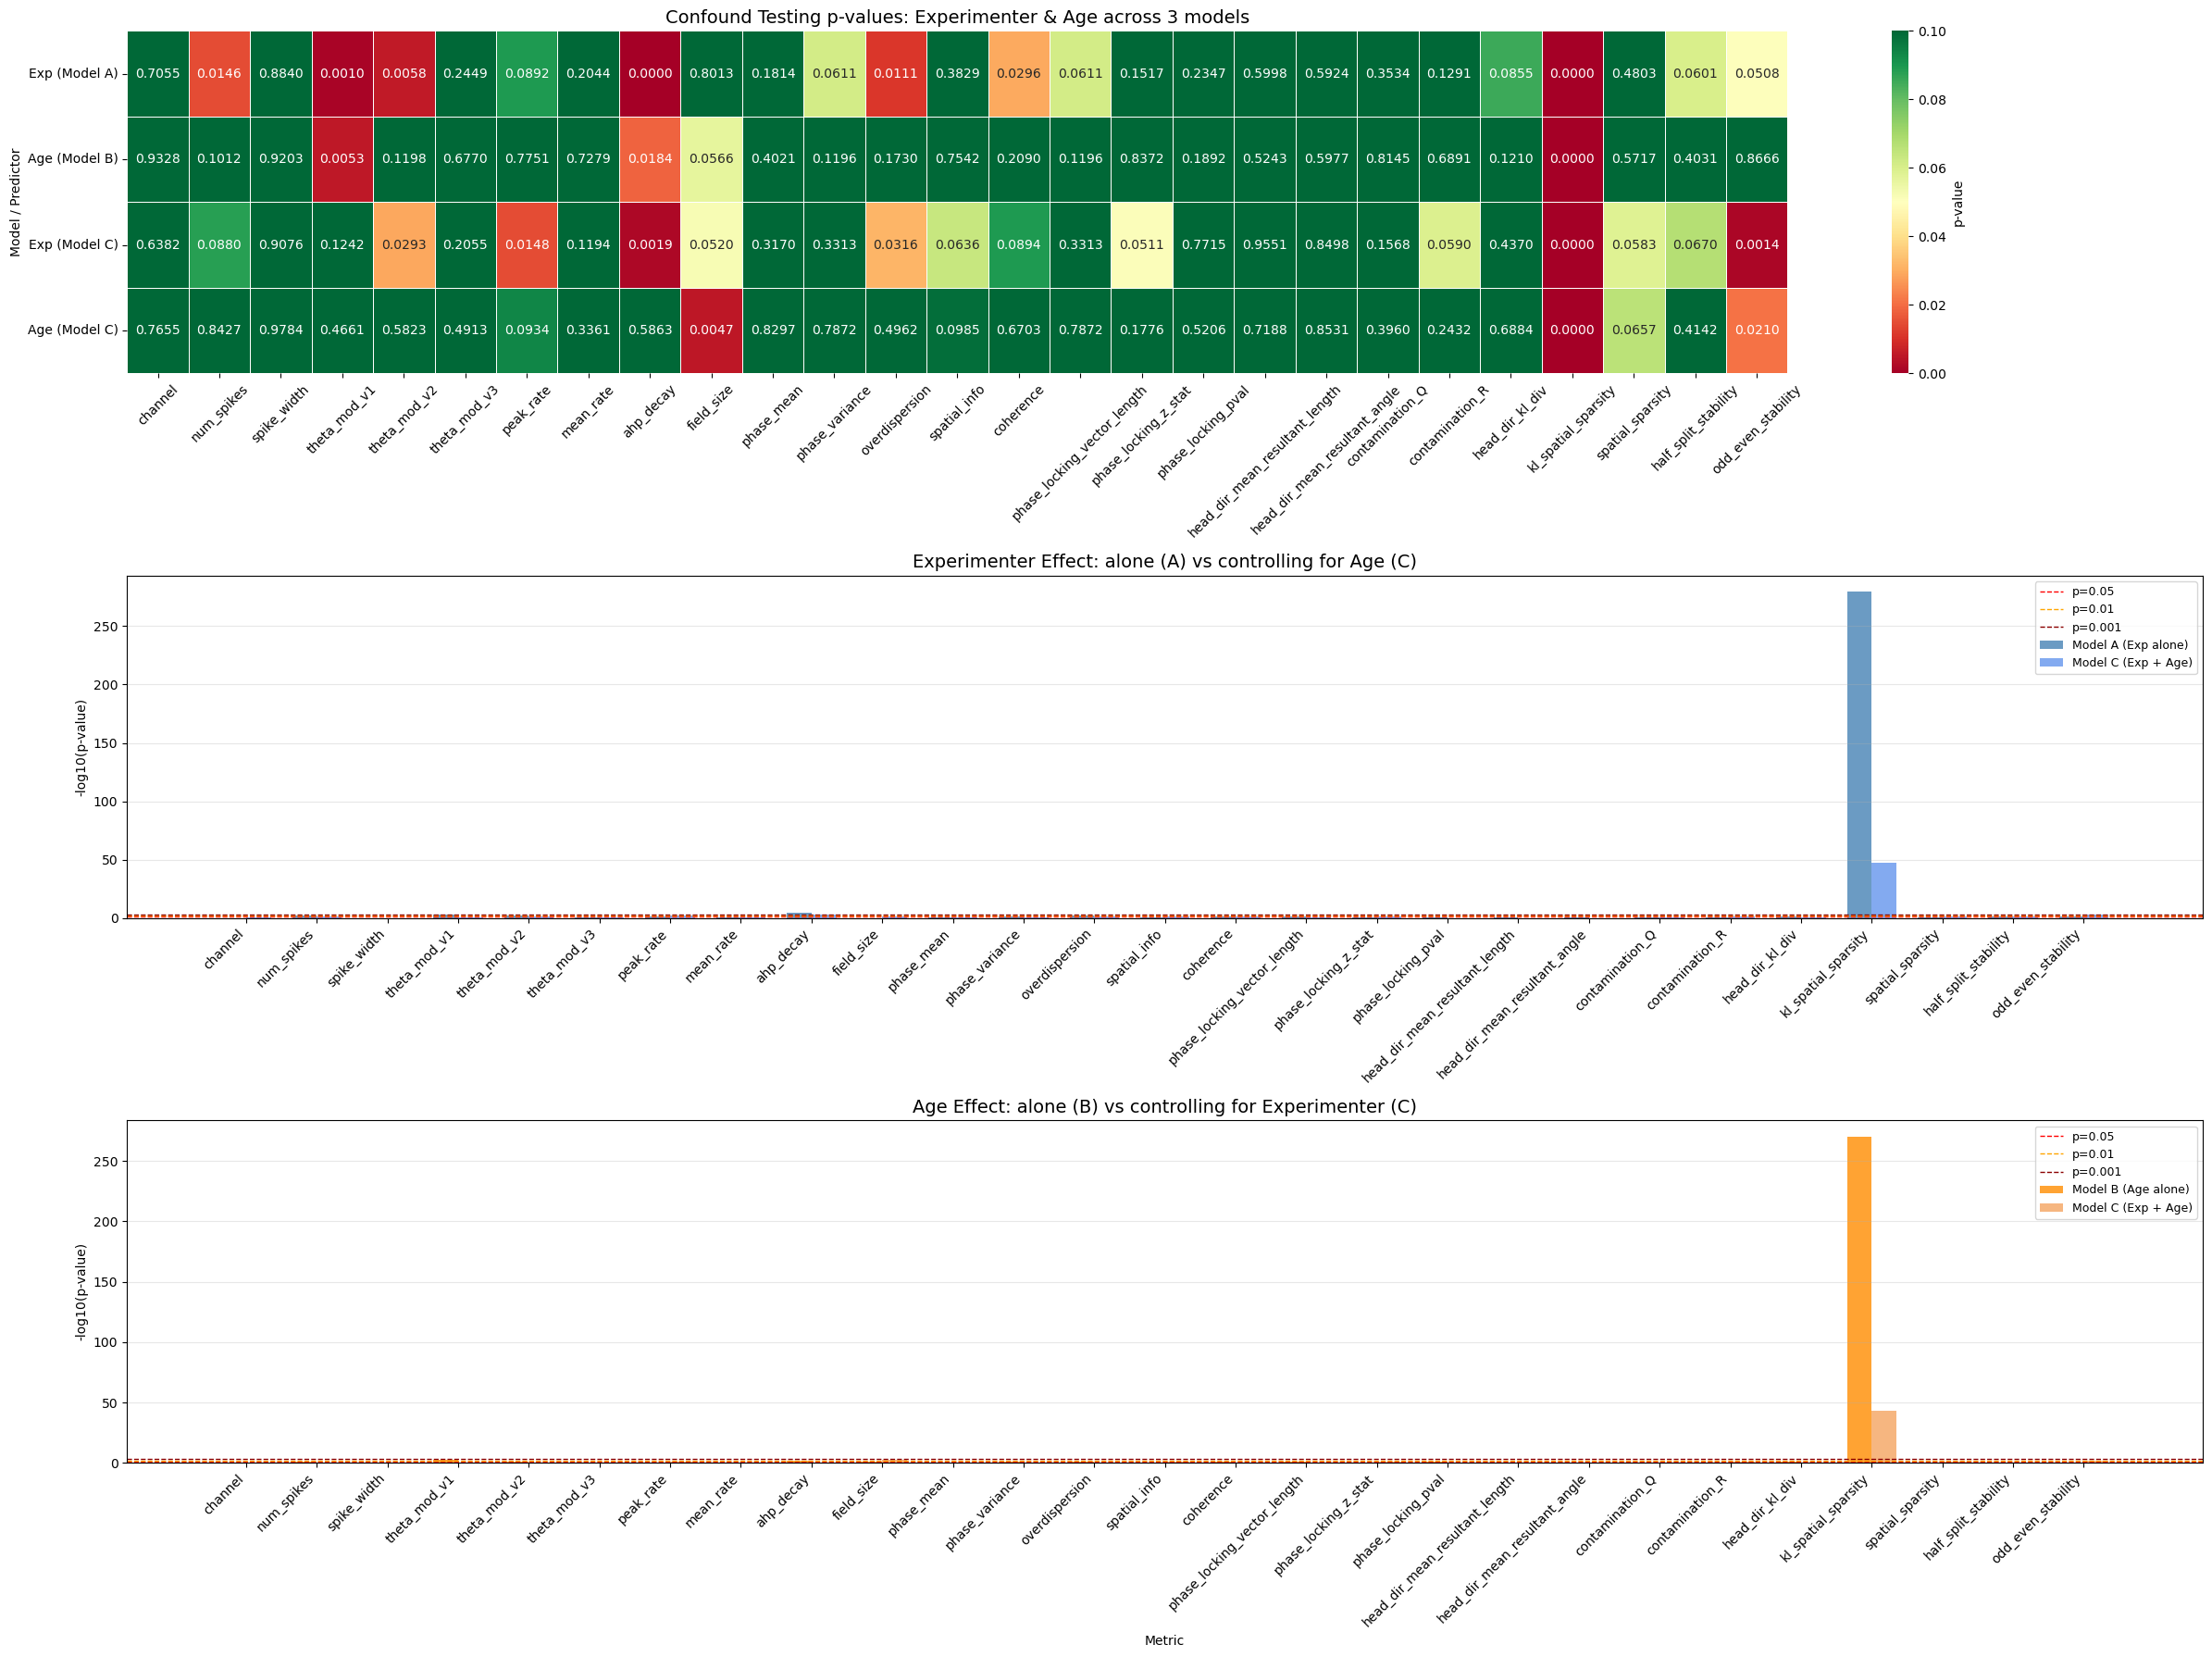

In [ ]:
"""Visualization of Confound Testing results (3-model comparison)
Plot 1: Heatmap of p-values across all models (A, B, C)
Plot 2: Grouped bar plot — Experimenter p-values: Model A (alone) vs Model C (joint)
Plot 3: Grouped bar plot — Age p-values: Model B (alone) vs Model C (joint)
"""

import seaborn as sns

fig, axes = plt.subplots(3, 1, figsize=(24, 18))

# ── Plot 1: Heatmap of all p-values ────────────────────────────────────────
heatmap_data = df_confound[['metric', 'A_p_Experimenter', 'B_p_Age',
                             'C_p_Experimenter', 'C_p_Age']].set_index('metric')
heatmap_data.columns = ['Exp (Model A)', 'Age (Model B)', 'Exp (Model C)', 'Age (Model C)']

sns.heatmap(heatmap_data.T, annot=True, fmt='.4f', cmap='RdYlGn',
            vmin=0, vmax=0.1, ax=axes[0], cbar_kws={'label': 'p-value'},
            linewidths=0.5)
axes[0].set_title('Confound Testing p-values: Experimenter & Age across 3 models', fontsize=14)
axes[0].set_ylabel('Model / Predictor')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=45)
axes[0].tick_params(axis='y', rotation=0)


# ── Plot 2: Experimenter — Model A vs Model C ─────────────────────────────
x = np.arange(len(df_confound))
width = 0.35

neg_log_A = -np.log10(df_confound['A_p_Experimenter'].clip(lower=1e-300))
neg_log_C_exp = -np.log10(df_confound['C_p_Experimenter'].clip(lower=1e-300))

axes[1].bar(x - width/2, neg_log_A, width, label='Model A (Exp alone)', color='steelblue', alpha=0.8)
axes[1].bar(x + width/2, neg_log_C_exp, width, label='Model C (Exp + Age)', color='cornflowerblue', alpha=0.8)
axes[1].axhline(y=-np.log10(0.05), color='red', linestyle='--', linewidth=1, label='p=0.05')
axes[1].axhline(y=-np.log10(0.01), color='orange', linestyle='--', linewidth=1, label='p=0.01')
axes[1].axhline(y=-np.log10(0.001), color='darkred', linestyle='--', linewidth=1, label='p=0.001')
axes[1].set_xticks(x)
axes[1].set_xticklabels(df_confound['metric'], rotation=45, ha='right')
axes[1].set_ylabel('-log10(p-value)')
axes[1].set_title('Experimenter Effect: alone (A) vs controlling for Age (C)', fontsize=14)
axes[1].legend(loc='upper right', fontsize=9)
axes[1].grid(axis='y', alpha=0.3)

# ── Plot 3: Age — Model B vs Model C ──────────────────────────────────────
neg_log_B = -np.log10(df_confound['B_p_Age'].clip(lower=1e-300))
neg_log_C_age = -np.log10(df_confound['C_p_Age'].clip(lower=1e-300))

axes[2].bar(x - width/2, neg_log_B, width, label='Model B (Age alone)', color='darkorange', alpha=0.8)
axes[2].bar(x + width/2, neg_log_C_age, width, label='Model C (Exp + Age)', color='sandybrown', alpha=0.8)
axes[2].axhline(y=-np.log10(0.05), color='red', linestyle='--', linewidth=1, label='p=0.05')
axes[2].axhline(y=-np.log10(0.01), color='orange', linestyle='--', linewidth=1, label='p=0.01')
axes[2].axhline(y=-np.log10(0.001), color='darkred', linestyle='--', linewidth=1, label='p=0.001')
axes[2].set_xticks(x)
axes[2].set_xticklabels(df_confound['metric'], rotation=45, ha='right')
axes[2].set_ylabel('-log10(p-value)')
axes[2].set_xlabel('Metric')
axes[2].set_title('Age Effect: alone (B) vs controlling for Experimenter (C)', fontsize=14)
axes[2].legend(loc='upper right', fontsize=9)
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()

confound_plot_path = os.path.join(OPEN_FIELD_OUTDIR, "4b.open_field_confound_testing_visualization.pdf")
fig.savefig(confound_plot_path, bbox_inches='tight')
print(f"Saved to: {confound_plot_path}")
plt.show()

In [ ]:
"""Boxplots by Experimenter, annotated with confound test results (LMM)
- Model A p-value: Experimenter effect alone
- Model C p-values: Experimenter and Age effects in joint model
"""

experimenters = sorted(df_open_field["Experimenter"].dropna().unique().tolist())

# Build lookup from confound results
confound_lookup = {}
if 'df_confound' in dir():
    for _, row in df_confound.iterrows():
        confound_lookup[row['metric']] = row

pdf_experimenter_path = os.path.join(
    OPEN_FIELD_OUTDIR,
    "5.open_field_boxplots_by_experimenter.pdf"
)

experimenter_stats = []
cols_to_plot = [c for c in numeric_cols if c not in ["tetrode", "cluster", "mouse_name", "Age_weeks"]]

with PdfPages(pdf_experimenter_path) as pdf:
    # Title page
    fig = plt.figure(figsize=(11.69, 8.27))
    txt = (
        "Open field dataset — Boxplots by Experimenter\n"
        f"Rows: {len(df_open_field):,} | Columns: {df_open_field.shape[1]:,}\n"
        f"Experimenters: {', '.join(map(str, experimenters))}\n\n"
        "Each page shows a boxplot + jittered points per Experimenter,\n"
        "annotated with LMM confound test results:\n"
        "  Model A: Experimenter only + (1|mouse)\n"
        "  Model C: Experimenter + Age_weeks + (1|mouse)\n"
    )
    fig.text(0.05, 0.9, txt, fontsize=16, va="top")
    plt.axis("off")
    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

    for col in cols_to_plot:
        fig = plt.figure(figsize=(11.69, 8.27))
        ax = fig.add_subplot(111)

        groups = []
        ns = []
        for exp in experimenters:
            vals = df_open_field.loc[df_open_field["Experimenter"] == exp, col].dropna().values.astype(float)
            groups.append(vals)
            ns.append(len(vals))

        # Boxplot + jittered points
        ax.boxplot(groups, showfliers=False, medianprops=dict(color="black", linewidth=1))
        for i, vals in enumerate(groups, start=1):
            if len(vals) == 0:
                continue
            x = i + rng.uniform(-0.12, 0.12, size=len(vals))
            ax.scatter(x, vals, s=6, alpha=0.4)

        ax.set_xticks(range(1, len(experimenters) + 1))
        ax.set_xticklabels([str(e) for e in experimenters], rotation=0)
        ax.set_xlabel("Experimenter")
        ax.set_ylabel(col)

        # Build annotation from confound test
        cr = confound_lookup.get(col)
        if cr is not None:
            p_a = cr['A_p_Experimenter']
            p_c_exp = cr['C_p_Experimenter']
            p_c_age = cr['C_p_Age']

            stat_note = (
                f"LMM Confound Test\n"
                f"Model A (Exp only):     p={p_a:.3g} ({cr['A_sig']})\n"
                f"Model C (Exp|Age):      p={p_c_exp:.3g} ({cr['C_sig_Exp']})\n"
                f"Model C (Age|Exp):      p={p_c_age:.3g} ({cr['C_sig_Age']})\n"
            )

            # Color title by significance in Model C
            if cr['C_sig_Exp'] in ['*', '**', '***']:
                title_color = 'red'
                verdict = f" — Experimenter effect ({cr['C_sig_Exp']})"
            elif cr['A_sig'] in ['*', '**', '***'] and cr['C_sig_Exp'] == 'ns':
                title_color = 'orange'
                verdict = " — collinearity with Age"
            else:
                title_color = 'black'
                verdict = ""
        else:
            stat_note = "No confound test available"
            title_color = 'black'
            verdict = ""

        # Group summaries
        for exp, vals in zip(experimenters, groups):
            if len(vals) > 0:
                stat_note += f"\n{exp}: n={len(vals)}, mean={np.mean(vals):.3g}, med={np.median(vals):.3g}"

        ax.set_title(f"{col} by Experimenter{verdict}", color=title_color, fontsize=13, fontweight='bold')

        ax.text(
            0.98, 0.98, stat_note,
            transform=ax.transAxes,
            ha="right", va="top",
            fontsize=10,
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="black", alpha=0.8),
        )

        # Collect stats
        if cr is not None:
            experimenter_stats.append({
                "column": col,
                **{f"n_{exp}": n for exp, n in zip(experimenters, ns)},
                **{f"mean_{exp}": float(np.mean(g)) for exp, g in zip(experimenters, groups) if len(g) > 0},
                **{f"median_{exp}": float(np.median(g)) for exp, g in zip(experimenters, groups) if len(g) > 0},
                "A_p_Experimenter": float(cr['A_p_Experimenter']),
                "A_sig": cr['A_sig'],
                "C_p_Experimenter": float(cr['C_p_Experimenter']),
                "C_sig_Exp": cr['C_sig_Exp'],
                "C_p_Age": float(cr['C_p_Age']),
                "C_sig_Age": cr['C_sig_Age'],
            })

        fig.tight_layout()
        pdf.savefig(fig)
        plt.close(fig)

print(f"Experimenter boxplots saved to: {pdf_experimenter_path}")

df_experimenter_stats = pd.DataFrame(experimenter_stats)
display_df("Experimenter Differences (from LMM Confound Testing)", df_experimenter_stats)

experimenter_stats_path = os.path.join(OPEN_FIELD_OUTDIR, "5.open_field_experimenter_statistics.csv")
df_experimenter_stats.to_csv(experimenter_stats_path, index=False)
print(f"\nExperimenter statistics saved to: {experimenter_stats_path}")

Experimenter boxplots saved to: /Users/loukia/Library/CloudStorage/Dropbox-UCL/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/Analysis/OF_concat/OpenField_QC_outputs/5.open_field_boxplots_by_experimenter.pdf
Experimenter Differences (from LMM Confound Testing)


,column,n_Loukia,n_Ruth,mean_Loukia,mean_Ruth,median_Loukia,median_Ruth,A_p_Experimenter,A_sig,C_p_Experimenter,C_sig_Exp,C_p_Age,C_sig_Age
0,channel,750,328,4.262667,4.274390,4.000000e+00,4.000000e+00,7.054797e-01,ns,6.382113e-01,ns,7.654932e-01,ns
1,num_spikes,750,328,3551.260000,2314.082317,1.355500e+03,9.355000e+02,1.457655e-02,*,8.801504e-02,ns,8.427103e-01,ns
2,spike_width,750,328,401.142857,373.631160,4.693878e+02,4.285714e+02,8.840343e-01,ns,9.076422e-01,ns,9.783633e-01,ns
3,theta_mod_v1,750,328,-0.025156,-0.207642,1.138658e-01,-1.977124e-01,9.804470e-04,***,1.241964e-01,ns,4.661079e-01,ns
4,theta_mod_v2,740,318,0.770132,0.859099,1.000000e+00,1.000000e+00,5.805206e-03,**,2.927730e-02,*,5.822778e-01,ns
5,theta_mod_v3,750,328,0.058027,0.044235,3.680554e-02,2.532444e-02,2.448989e-01,ns,2.055272e-01,ns,4.912777e-01,ns
6,peak_rate,750,328,3.211382,2.559395,1.706799e+00,1.251255e+00,8.920706e-02,ns,1.477771e-02,*,9.344884e-02,ns
7,mean_rate,750,328,1.718422,1.442669,6.599054e-01,5.472770e-01,2.044413e-01,ns,1.193671e-01,ns,3.360751e-01,ns
8,ahp_decay,669,279,349.797490,412.034483,3.536557e+02,3.937877e+02,2.318968e-05,***,1.890199e-03,**,5.862927e-01,ns
9,field_size,750,328,672.081061,636.248929,7.587914e+02,6.693560e+02,8.013498e-01,ns,5.204405e-02,ns,4.734508e-03,**



Experimenter statistics saved to: /Users/loukia/Library/CloudStorage/Dropbox-UCL/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/Analysis/OF_concat/OpenField_QC_outputs/5.open_field_experimenter_statistics.csv


In [ ]:
"""Confound testing split by Cell type
LMM: y ~ Experimenter + Age_weeks_z + (1|mouse_name), run separately per cell type
+ Boxplots: metric by Cell type, hue = Experimenter
"""

import warnings
warnings.filterwarnings('ignore')
import statsmodels.formula.api as smf

CELLTYPE_COL = _find_col(df_open_field, ["Cell Type", "Cell type", "cell_type", "celltype"])
print(f"Using CELLTYPE_COL = {CELLTYPE_COL}")

cell_types = sorted(df_open_field[CELLTYPE_COL].dropna().unique().tolist())
cols_to_use = [c for c in numeric_cols if c not in ["tetrode", "cluster", "mouse_name", "Age_weeks", "Experimenter"]]

def _sig(p):
    if not np.isfinite(p): return 'NA'
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'ns'

# ── 1. Confound test per cell type ─────────────────────────────────────────
confound_by_ct = []

for ct in cell_types:
    ct_data = df_open_field[df_open_field[CELLTYPE_COL] == ct].copy()
    print(f"\n--- {ct} (n={len(ct_data)}, mice={ct_data['mouse_name'].nunique()}) ---")

    for col in cols_to_use:
        sub = ct_data[[col, 'Experimenter', 'Age_weeks', 'mouse_name']].dropna().copy()
        if len(sub) < 10 or sub['mouse_name'].nunique() < 3:
            continue

        sub['Age_weeks_z'] = (sub['Age_weeks'] - sub['Age_weeks'].mean()) / sub['Age_weeks'].std()
        sub = sub.rename(columns={col: 'y'})

        row = {'cell_type': ct, 'metric': col, 'n_obs': len(sub),
               'n_animals': sub['mouse_name'].nunique()}

        # Model A: Experimenter only
        try:
            fitA = smf.mixedlm("y ~ C(Experimenter)", data=sub, groups=sub["mouse_name"]).fit(reml=True)
            exp_keys = [k for k in fitA.pvalues.index if 'Experimenter' in k]
            row['A_p_Exp'] = float(fitA.pvalues[exp_keys[0]]) if exp_keys else np.nan
        except:
            row['A_p_Exp'] = np.nan

        # Model B: Age only
        try:
            fitB = smf.mixedlm("y ~ Age_weeks_z", data=sub, groups=sub["mouse_name"]).fit(reml=True)
            row['B_p_Age'] = float(fitB.pvalues.get('Age_weeks_z', np.nan))
        except:
            row['B_p_Age'] = np.nan

        # Model C: Both
        try:
            fitC = smf.mixedlm("y ~ C(Experimenter) + Age_weeks_z", data=sub, groups=sub["mouse_name"]).fit(reml=True)
            exp_keys = [k for k in fitC.pvalues.index if 'Experimenter' in k]
            row['C_p_Exp'] = float(fitC.pvalues[exp_keys[0]]) if exp_keys else np.nan
            row['C_p_Age'] = float(fitC.pvalues.get('Age_weeks_z', np.nan))
        except:
            row['C_p_Exp'] = np.nan
            row['C_p_Age'] = np.nan

        row['A_sig'] = _sig(row['A_p_Exp'])
        row['B_sig'] = _sig(row['B_p_Age'])
        row['C_sig_Exp'] = _sig(row['C_p_Exp'])
        row['C_sig_Age'] = _sig(row['C_p_Age'])

        confound_by_ct.append(row)
        print(f"  {col:40s} n={len(sub):<5d} Exp(A):{row['A_sig']}  Age(B):{row['B_sig']}  Exp(C):{row['C_sig_Exp']}  Age(C):{row['C_sig_Age']}")

df_confound_ct = pd.DataFrame(confound_by_ct)
display_df("Confound Testing by Cell Type", df_confound_ct)

confound_ct_path = os.path.join(OPEN_FIELD_OUTDIR, "6.open_field_confound_by_celltype.csv")
df_confound_ct.to_csv(confound_ct_path, index=False)
print(f"\nSaved to: {confound_ct_path}")

# ── 2. Summary comparison ─────────────────────────────────────────────────
print("\n=== METRICS WITH EXPERIMENTER EFFECT IN MODEL C, BY CELL TYPE ===")
for ct in cell_types:
    sub = df_confound_ct[df_confound_ct['cell_type'] == ct]
    sig_metrics = sub[sub['C_sig_Exp'].isin(['*','**','***'])]['metric'].tolist()
    print(f"\n{ct}: {len(sig_metrics)} metrics")
    if sig_metrics:
        print(f"  {', '.join(sig_metrics)}")

# Build lookup for boxplot annotation
confound_ct_lookup = {}
for _, row in df_confound_ct.iterrows():
    confound_ct_lookup[(row['cell_type'], row['metric'])] = row

# ── 3. Boxplots: metric by Cell type, hue = Experimenter ──────────────────
pdf_path = os.path.join(OPEN_FIELD_OUTDIR, "6.open_field_boxplots_by_experimenter_and_celltype.pdf")

exp_levels = sorted(df_open_field['Experimenter'].dropna().unique().tolist())
hue_order = [h for h in ["Ruth", "Loukia"] if h in exp_levels] or exp_levels
palette = {
    "Ruth": sns.color_palette("Blues", 6)[2],
    "Loukia": sns.color_palette("Oranges", 6)[2],
}

with PdfPages(pdf_path) as pdf:
    fig = plt.figure(figsize=(11.69, 8.27))
    txt = (
        "Open field — Boxplots by Experimenter & Cell type\n"
        f"Cell types: {', '.join(cell_types)}\n"
        f"Experimenters: {', '.join(exp_levels)}\n\n"
        "Annotated with LMM confound test (per cell type):\n"
        "  Model A: Exp only | Model C: Exp + Age\n"
    )
    fig.text(0.05, 0.9, txt, fontsize=14, va="top")
    plt.axis("off")
    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

    for col in cols_to_use:
        plot_data = df_open_field[[col, 'Experimenter', CELLTYPE_COL]].dropna()
        if plot_data.empty or plot_data[CELLTYPE_COL].nunique() < 2:
            continue

        plot_data['Experimenter'] = plot_data['Experimenter'].astype(str).str.strip()

        fig = plt.figure(figsize=(11.69, 8.27))
        ax = fig.add_subplot(111)

        sns.boxplot(data=plot_data, x=CELLTYPE_COL, y=col, hue='Experimenter',
                    hue_order=hue_order, palette=palette, showfliers=False, ax=ax)
        sns.stripplot(data=plot_data, x=CELLTYPE_COL, y=col, hue='Experimenter',
                      hue_order=hue_order, palette=palette, dodge=True, jitter=0.28,
                      size=2.5, alpha=0.35, linewidth=0.25, ax=ax)

        # Annotation: confound test per cell type
        annot_lines = []
        has_sig = False
        for ct in cell_types:
            cr = confound_ct_lookup.get((ct, col))
            if cr is not None:
                line = f"{ct}: Exp(A)={cr['A_sig']}  Exp(C)={cr['C_sig_Exp']}  Age(C)={cr['C_sig_Age']}"
                annot_lines.append(line)
                if cr['C_sig_Exp'] in ['*','**','***']:
                    has_sig = True

        stat_note = "LMM Confound (per cell type)\n" + "\n".join(annot_lines)
        ax.text(0.98, 0.98, stat_note, transform=ax.transAxes, ha="right", va="top",
                fontsize=10, bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                                        edgecolor="black", alpha=0.8))

        title_color = 'red' if has_sig else 'black'
        ax.set_title(f"{col} by Cell type (hue=Experimenter)", color=title_color,
                     fontsize=13, fontweight='bold')

        handles, labels = ax.get_legend_handles_labels()
        by_label = dict(zip(labels, handles))
        ax.legend(by_label.values(), by_label.keys(), title='Experimenter',
                  bbox_to_anchor=(1.02, 1), loc="upper left")

        ax.set_xlabel(CELLTYPE_COL)
        ax.set_ylabel(col)
        ax.tick_params(axis="x", rotation=45)
        fig.tight_layout()
        pdf.savefig(fig)
        plt.close(fig)

print(f"Saved boxplots PDF to: {pdf_path}")

Using CELLTYPE_COL = Cell type

--- Interneuron (n=347, mice=17) ---
  channel                                  n=347   Exp(A):ns  Age(B):ns  Exp(C):ns  Age(C):ns
  num_spikes                               n=347   Exp(A):**  Age(B):ns  Exp(C):ns  Age(C):ns
  spike_width                              n=347   Exp(A):ns  Age(B):ns  Exp(C):ns  Age(C):ns
  theta_mod_v1                             n=347   Exp(A):ns  Age(B):ns  Exp(C):ns  Age(C):ns
  theta_mod_v2                             n=339   Exp(A):*  Age(B):ns  Exp(C):*  Age(C):ns
  theta_mod_v3                             n=347   Exp(A):ns  Age(B):ns  Exp(C):ns  Age(C):ns
  peak_rate                                n=347   Exp(A):ns  Age(B):ns  Exp(C):*  Age(C):ns
  mean_rate                                n=347   Exp(A):ns  Age(B):ns  Exp(C):*  Age(C):ns
  ahp_decay                                n=317   Exp(A):**  Age(B):ns  Exp(C):*  Age(C):ns
  field_size                               n=347   Exp(A):ns  Age(B):**  Exp(C):ns  Age(C)

,cell_type,metric,n_obs,n_animals,A_p_Exp,B_p_Age,C_p_Exp,C_p_Age,A_sig,B_sig,C_sig_Exp,C_sig_Age
0,Interneuron,channel,347,17,7.057108e-01,6.851639e-01,2.860057e-01,2.812949e-01,ns,ns,ns,ns
1,Interneuron,num_spikes,347,17,9.608694e-03,6.143663e-02,6.835772e-02,7.997362e-01,**,ns,ns,ns
2,Interneuron,spike_width,347,17,7.278539e-01,7.257151e-01,8.955274e-01,9.013401e-01,ns,ns,ns,ns
3,Interneuron,theta_mod_v1,347,17,3.976732e-01,3.080071e-01,9.335745e-01,5.829802e-01,ns,ns,ns,ns
4,Interneuron,theta_mod_v2,339,17,1.026011e-02,1.754087e-01,1.800081e-02,3.561679e-01,*,ns,*,ns
5,Interneuron,theta_mod_v3,347,17,2.152457e-01,7.691378e-01,1.126748e-01,3.006528e-01,ns,ns,ns,ns
6,Interneuron,peak_rate,347,17,6.072012e-02,4.733480e-01,2.648720e-02,1.973014e-01,ns,ns,*,ns
7,Interneuron,mean_rate,347,17,9.940375e-02,5.483559e-01,4.558649e-02,2.234740e-01,ns,ns,*,ns
8,Interneuron,ahp_decay,317,17,1.329276e-03,7.390786e-02,1.027370e-02,4.676759e-01,**,ns,*,ns
9,Interneuron,field_size,347,17,1.261765e-01,5.593779e-03,6.019446e-01,3.165514e-02,ns,**,ns,*



Saved to: /Users/loukia/Library/CloudStorage/Dropbox-UCL/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/Analysis/OF_concat/OpenField_QC_outputs/6.open_field_confound_by_celltype.csv

=== METRICS WITH EXPERIMENTER EFFECT IN MODEL C, BY CELL TYPE ===

Interneuron: 9 metrics
  theta_mod_v2, peak_rate, mean_rate, ahp_decay, phase_mean, overdispersion, phase_locking_z_stat, kl_spatial_sparsity, odd_even_stability

Pyramidal: 11 metrics
  spike_width, theta_mod_v1, theta_mod_v2, peak_rate, field_size, spatial_info, coherence, kl_spatial_sparsity, spatial_sparsity, half_split_stability, odd_even_stability
Saved boxplots PDF to: /Users/loukia/Library/CloudStorage/Dropbox-UCL/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/Analysis/OF_concat/OpenField_QC_outputs/6.open_field_boxplots_by_experimenter_and_celltype.pdf


# Question No1: What shall I do for the colinearity effect?
---

### Metrics unaffected by Experimenter or Age (safe — no covariates needed)

These are clean for both cell types: `channel`, `theta_mod_v3`, `phase_variance`, `phase_locking_vector_length`, `phase_locking_pval`, `head_dir_mean_resultant_length`, `head_dir_mean_resultant_angle`, `contamination_Q`, `contamination_R`, `head_dir_kl_div`, `phase_mean` (pyramidal only).

---

### `kl_spatial_sparsity` — strong confound in BOTH cell types

Both Experimenter and Age are highly significant (\*\*\*) in every model for both cell types. This metric is fundamentally different between experimenters and ages. **Treat results for this metric with extreme caution** — any Genotype effect will be hard to trust even with covariates.

---

### Experimenter effects that survive in Model C (independent of Age)

| Metric | Interneuron | Pyramidal | Interpretation |
|---|---|---|---|
| `theta_mod_v2` | \* | \* | Both cell types affected |
| `peak_rate` | \* | \* | Both cell types affected |
| `odd_even_stability` | \* | \*\*\* | Both, stronger in pyramidal |
| `ahp_decay` | \* | ns | Interneuron-specific |
| `overdispersion` | \*\* | ns | Interneuron-specific |
| `mean_rate` | \* | ns | Interneuron-specific |
| `phase_locking_z_stat` | \* | ns | Interneuron-specific |
| `phase_mean` | \* | ns | Interneuron-specific |
| `spike_width` | ns | \* | Pyramidal-specific |
| `theta_mod_v1` | ns | \* | Pyramidal-specific |
| `spatial_info` | ns | \* | Pyramidal-specific |
| `coherence` | ns | \* | Pyramidal-specific |
| `spatial_sparsity` | ns | \*\* | Pyramidal-specific |
| `half_split_stability` | ns | \*\* | Pyramidal-specific |
| `field_size` | ns | \* | Pyramidal-specific |

---

### Age effects that survive in Model C (independent of Experimenter)

| Metric | Interneuron | Pyramidal |
|---|---|---|
| `field_size` | \* | \*\* |
| `peak_rate` | ns | \* |
| `half_split_stability` | \* | \* |
| `spatial_sparsity` | ns | \* |
| `odd_even_stability` | ns | \*\* |

These Age effects are mostly in pyramidal cells and relate to spatial coding quality — older mice may have degraded place field properties.

---

### Collinearity cases (significant alone, ns in joint model)

- **`num_spikes`** (interneuron): A:\*\*, C:ns — can't separate from Age
- **`spatial_info`** (interneuron): A:\* and B:\*, both C:ns — collinearity
- **`ahp_decay`** (pyramidal): A:\*, C:ns — can't separate from Age
- **`theta_mod_v1`** (interneuron): A:ns everywhere — no issue

---

### Practical summary

**Interneurons** have more Experimenter effects on firing properties (rate, AHP, phase locking), suggesting recording/sorting differences affect this cell type more.

**Pyramidal cells** have more effects on spatial coding measures (field size, coherence, spatial info, stability), which is concerning since these are typically your primary outcome variables for place cells.

**For your Genotype models, per cell type:**

- **Interneurons**: add `C(Experimenter)` as covariate for `theta_mod_v2`, `peak_rate`, `mean_rate`, `ahp_decay`, `overdispersion`, `phase_mean`, `phase_locking_z_stat`, `odd_even_stability`, `kl_spatial_sparsity`
- **Pyramidal cells**: add `C(Experimenter) + Age_weeks_z` for `field_size`, `odd_even_stability`, `half_split_stability`, `spatial_sparsity`, `peak_rate`; add `C(Experimenter)` for `spike_width`, `theta_mod_v1`, `theta_mod_v2`, `spatial_info`, `coherence`, `kl_spatial_sparsity`



For the collinearity cases (`num_spikes` in interneurons, `spatial_info` in interneurons, `ahp_decay` in pyramidal), you have a few options:

**Option 1 (recommended): Add Experimenter as the covariate anyway**

Since Experimenter is the variable you can actually "control for" in your design (it's a known grouping), include it as a covariate even though you can't cleanly separate it from Age:

```
y ~ Genotype + C(Experimenter) + (1|mouse_name)
```

This is conservative — it removes any variance shared between Experimenter and Age, so you only detect Genotype effects that are independent of both. The downside is slightly reduced power.

**Option 2: Report both models and compare**

Run your Genotype model twice — once without and once with the covariate — and report both:

```
Model 1: y ~ Genotype + (1|mouse_name)
Model 2: y ~ Genotype + C(Experimenter) + (1|mouse_name)
```

If the Genotype effect is consistent across both, it's robust regardless of the confound. If it disappears when you add Experimenter, flag it as potentially confounded.

**Option 3: Don't add a covariate, but note the caveat**

Since neither Experimenter nor Age had an independent effect in Model C (both went ns), the true effect may be small or nonexistent. You can leave the model simple and note in your write-up that these metrics showed a marginal association with Experimenter/Age that couldn't be disentangled.

---

**In practice**, Option 1 is the safest for a paper — reviewers are more likely to question *missing* covariates than *extra* ones. For just 3 metrics out of 27, adding `C(Experimenter)` across the board is simpler than maintaining separate formulas per metric.

#### Question No2: Do you mean add experimenter as a covariate for all the analyses?

No — you have two reasonable strategies:

Per-metric approach (more precise): Only add C(Experimenter) for the metrics where the confound test flagged a significant effect. For unaffected metrics (e.g. phase_variance, contamination_Q), keep the simpler model.

Blanket approach (simpler, more defensible): Add C(Experimenter) to all metrics. This is easier to justify to reviewers ("we controlled for Experimenter throughout") and avoids having different model formulas for different metrics. If Experimenter has no real effect on a given metric, including it costs you almost nothing — just a tiny bit of power.

Given that ~9–11 metrics per cell type are affected (roughly a third to half), the blanket approach is probably cleaner for a paper. One formula everywhere:

And for the handful of metrics where Age also had an independent effect in Model C (mainly field_size, odd_even_stability, half_split_stability in pyramidal cells), upgrade to:

y ~ Genotype + C(Experimenter) + Age_weeks_z + (1|mouse_name)

In [30]:
"""Confound testing split by Genotype and Cell type
LMM: y ~ Experimenter + Age_weeks_z + (1|mouse_name), run within each Genotype × Cell type
+ Boxplots: metric by Cell type, hue = Experimenter, split by Genotype
"""

import warnings
warnings.filterwarnings('ignore')
import statsmodels.formula.api as smf

CELLTYPE_COL = _find_col(df_open_field, ["Cell Type", "Cell type", "cell_type", "celltype"])
GENOTYPE_COL = _find_col(df_open_field, ["Phenotype", "genotype", "geno", "genotype_group", "Genotype group"])
print(f"Using CELLTYPE_COL = {CELLTYPE_COL}")
print(f"Using GENOTYPE_COL = {GENOTYPE_COL}")

cell_types = sorted(df_open_field[CELLTYPE_COL].dropna().unique().tolist())
genotype_levels = sorted(df_open_field[GENOTYPE_COL].dropna().unique().tolist())
cols_to_use = [c for c in numeric_cols if c not in ["tetrode", "cluster", "mouse_name", "Age_weeks", "Experimenter"]]

print(f"Genotypes: {genotype_levels}")
print(f"Cell types: {cell_types}")

def _sig(p):
    if not np.isfinite(p): return 'NA'
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'ns'

# ── 1. LMM confound test per Genotype × Cell type ─────────────────────────
confound_rows = []

for geno in genotype_levels:
    for ct in cell_types:
        subset = df_open_field[
            (df_open_field[GENOTYPE_COL] == geno) &
            (df_open_field[CELLTYPE_COL] == ct)
        ].copy()

        print(f"\n--- {geno} | {ct} (n={len(subset)}, mice={subset['mouse_name'].nunique()}) ---")

        for col in cols_to_use:
            sub = subset[[col, 'Experimenter', 'Age_weeks', 'mouse_name']].dropna().copy()
            if len(sub) < 10 or sub['mouse_name'].nunique() < 3:
                continue

            sub['Age_weeks_z'] = (sub['Age_weeks'] - sub['Age_weeks'].mean()) / sub['Age_weeks'].std()
            sub = sub.rename(columns={col: 'y'})

            row = {'genotype': geno, 'cell_type': ct, 'metric': col,
                   'n_obs': len(sub), 'n_animals': sub['mouse_name'].nunique()}

            # Model A: Experimenter only
            try:
                fitA = smf.mixedlm("y ~ C(Experimenter)", data=sub, groups=sub["mouse_name"]).fit(reml=True)
                exp_keys = [k for k in fitA.pvalues.index if 'Experimenter' in k]
                row['A_p_Exp'] = float(fitA.pvalues[exp_keys[0]]) if exp_keys else np.nan
            except:
                row['A_p_Exp'] = np.nan

            # Model B: Age only
            try:
                fitB = smf.mixedlm("y ~ Age_weeks_z", data=sub, groups=sub["mouse_name"]).fit(reml=True)
                row['B_p_Age'] = float(fitB.pvalues.get('Age_weeks_z', np.nan))
            except:
                row['B_p_Age'] = np.nan

            # Model C: Both
            try:
                fitC = smf.mixedlm("y ~ C(Experimenter) + Age_weeks_z", data=sub, groups=sub["mouse_name"]).fit(reml=True)
                exp_keys = [k for k in fitC.pvalues.index if 'Experimenter' in k]
                row['C_p_Exp'] = float(fitC.pvalues[exp_keys[0]]) if exp_keys else np.nan
                row['C_p_Age'] = float(fitC.pvalues.get('Age_weeks_z', np.nan))
            except:
                row['C_p_Exp'] = np.nan
                row['C_p_Age'] = np.nan

            row['A_sig'] = _sig(row['A_p_Exp'])
            row['B_sig'] = _sig(row['B_p_Age'])
            row['C_sig_Exp'] = _sig(row['C_p_Exp'])
            row['C_sig_Age'] = _sig(row['C_p_Age'])

            confound_rows.append(row)
            print(f"  {col:40s} n={len(sub):<5d} Exp(A):{row['A_sig']}  Age(B):{row['B_sig']}  Exp(C):{row['C_sig_Exp']}  Age(C):{row['C_sig_Age']}")

df_confound_geno_ct = pd.DataFrame(confound_rows)
display_df("Confound Testing by Genotype × Cell Type", df_confound_geno_ct)

confound_save_path = os.path.join(
    OPEN_FIELD_OUTDIR,
    "7.open_field_confound_by_genotype_celltype.csv",
)
df_confound_geno_ct.to_csv(confound_save_path, index=False)
print(f"\nSaved to: {confound_save_path}")

# ── 2. Summary ────────────────────────────────────────────────────────────
print("\n=== METRICS WITH EXPERIMENTER EFFECT IN MODEL C, BY GENOTYPE × CELL TYPE ===")
for geno in genotype_levels:
    for ct in cell_types:
        sub = df_confound_geno_ct[(df_confound_geno_ct['genotype'] == geno) &
                                   (df_confound_geno_ct['cell_type'] == ct)]
        sig_metrics = sub[sub['C_sig_Exp'].isin(['*','**','***'])]['metric'].tolist()
        print(f"\n{geno} | {ct}: {len(sig_metrics)} metrics")
        if sig_metrics:
            print(f"  {', '.join(sig_metrics)}")

# Build lookup for boxplot annotation
confound_geno_ct_lookup = {}
for _, row in df_confound_geno_ct.iterrows():
    confound_geno_ct_lookup[(row['genotype'], row['cell_type'], row['metric'])] = row

# ── 3. Boxplots PDF split by Genotype ──────────────────────────────────────
pdf_path = os.path.join(
    OPEN_FIELD_OUTDIR,
    "7.open_field_boxplots_by_experimenter_and_celltype_split_by_genotype.pdf",
)

hue_order = [h for h in ["Ruth", "Loukia"]
             if h in df_open_field['Experimenter'].dropna().unique()]
palette = {
    "Ruth": sns.color_palette("Blues", 6)[2],
    "Loukia": sns.color_palette("Oranges", 6)[2],
}

with PdfPages(pdf_path) as pdf:
    # Title page
    fig = plt.figure(figsize=(11.69, 8.27))
    txt = (
        "Open field — Boxplots by Experimenter & Cell type, split by Genotype\n"
        f"Genotypes: {', '.join(genotype_levels)}\n"
        f"Cell types: {', '.join(cell_types)}\n\n"
        "Annotated with LMM confound test (per Genotype × Cell type):\n"
        "  Model A: Exp only | Model C: Exp + Age\n"
        "  Red title = Experimenter effect survives in Model C\n"
    )
    fig.text(0.05, 0.9, txt, fontsize=14, va="top")
    plt.axis("off")
    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

    for geno in genotype_levels:
        df_g = df_open_field[df_open_field[GENOTYPE_COL] == geno]

        # Genotype section title
        fig = plt.figure(figsize=(11.69, 8.27))
        fig.text(0.05, 0.9, f"{GENOTYPE_COL} = {geno}\nn = {len(df_g)}, mice = {df_g['mouse_name'].nunique()}",
                 fontsize=16, va="top")
        plt.axis("off")
        pdf.savefig(fig, bbox_inches="tight")
        plt.close(fig)

        for col in cols_to_use:
            plot_data = df_g[[col, 'Experimenter', CELLTYPE_COL]].dropna()
            if plot_data.empty or plot_data[CELLTYPE_COL].nunique() < 2:
                continue

            plot_data = plot_data.copy()
            plot_data['Experimenter'] = plot_data['Experimenter'].astype(str).str.strip()

            fig = plt.figure(figsize=(11.69, 8.27))
            ax = fig.add_subplot(111)

            local_hue = [h for h in hue_order if h in plot_data['Experimenter'].unique()]

            sns.boxplot(data=plot_data, x=CELLTYPE_COL, y=col, hue='Experimenter',
                        hue_order=local_hue, palette=palette, showfliers=False, ax=ax)
            sns.stripplot(data=plot_data, x=CELLTYPE_COL, y=col, hue='Experimenter',
                          hue_order=local_hue, palette=palette, dodge=True, jitter=0.2,
                          size=2.5, alpha=0.35, linewidth=0.25, ax=ax)

            # Annotation: confound test per cell type within this genotype
            annot_lines = []
            has_sig = False
            for ct in cell_types:
                cr = confound_geno_ct_lookup.get((geno, ct, col))
                if cr is not None:
                    line = f"{ct}: Exp(A)={cr['A_sig']}  Exp(C)={cr['C_sig_Exp']}  Age(C)={cr['C_sig_Age']}"
                    annot_lines.append(line)
                    if cr['C_sig_Exp'] in ['*', '**', '***']:
                        has_sig = True
                else:
                    annot_lines.append(f"{ct}: insufficient data")

            stat_note = f"LMM Confound ({geno})\n" + "\n".join(annot_lines)
            ax.text(0.98, 0.98, stat_note, transform=ax.transAxes, ha="right", va="top",
                    fontsize=10, bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                                            edgecolor="black", alpha=0.8))

            title_color = 'red' if has_sig else 'black'
            ax.set_title(f"{col} by Cell type | {GENOTYPE_COL}={geno}",
                         color=title_color, fontsize=13, fontweight='bold')

            handles, labels = ax.get_legend_handles_labels()
            by_label = dict(zip(labels, handles))
            ax.legend(by_label.values(), by_label.keys(), title='Experimenter',
                      bbox_to_anchor=(1.02, 1), loc="upper left")

            ax.set_xlabel(CELLTYPE_COL)
            ax.set_ylabel(col)
            ax.tick_params(axis="x", rotation=45)
            fig.tight_layout()
            pdf.savefig(fig)
            plt.close(fig)

print(f"Saved genotype-split boxplots PDF to: {pdf_path}")

Using CELLTYPE_COL = Cell type
Using GENOTYPE_COL = Genotype
Genotypes: ['NLGF', 'WT']
Cell types: ['Interneuron', 'Pyramidal']

--- NLGF | Interneuron (n=205, mice=9) ---
  channel                                  n=205   Exp(A):ns  Age(B):ns  Exp(C):ns  Age(C):ns
  num_spikes                               n=205   Exp(A):ns  Age(B):ns  Exp(C):ns  Age(C):ns
  spike_width                              n=205   Exp(A):ns  Age(B):ns  Exp(C):ns  Age(C):ns
  theta_mod_v1                             n=205   Exp(A):*  Age(B):ns  Exp(C):ns  Age(C):ns
  theta_mod_v2                             n=202   Exp(A):ns  Age(B):ns  Exp(C):ns  Age(C):ns
  theta_mod_v3                             n=205   Exp(A):ns  Age(B):ns  Exp(C):ns  Age(C):ns
  peak_rate                                n=205   Exp(A):ns  Age(B):ns  Exp(C):ns  Age(C):ns
  mean_rate                                n=205   Exp(A):ns  Age(B):ns  Exp(C):ns  Age(C):ns
  ahp_decay                                n=184   Exp(A):*  Age(B):ns  Exp(C

,genotype,cell_type,metric,n_obs,n_animals,A_p_Exp,B_p_Age,C_p_Exp,C_p_Age,A_sig,B_sig,C_sig_Exp,C_sig_Age
0,NLGF,Interneuron,channel,205,9,4.558927e-01,8.650623e-01,2.331630e-01,3.436227e-01,ns,ns,ns,ns
1,NLGF,Interneuron,num_spikes,205,9,1.302345e-01,1.674074e-01,5.440091e-01,8.868323e-01,ns,ns,ns,ns
2,NLGF,Interneuron,spike_width,205,9,7.435833e-01,4.721511e-01,5.785953e-01,4.084951e-01,ns,ns,ns,ns
3,NLGF,Interneuron,theta_mod_v1,205,9,1.400561e-02,1.087156e-01,8.178675e-02,4.632345e-01,*,ns,ns,ns
4,NLGF,Interneuron,theta_mod_v2,202,9,1.461923e-01,1.601730e-01,6.617709e-01,7.601067e-01,ns,ns,ns,ns
...,...,...,...,...,...,...,...,...,...,...,...,...,...
103,WT,Pyramidal,head_dir_kl_div,415,8,3.876161e-01,2.189665e-01,9.434352e-01,4.578913e-01,ns,ns,ns,ns
104,WT,Pyramidal,kl_spatial_sparsity,415,8,1.499149e-199,1.217183e-133,2.940880e-61,3.706675e-27,***,***,***,***
105,WT,Pyramidal,spatial_sparsity,415,8,3.419740e-01,9.388393e-01,1.523154e-01,2.878659e-01,ns,ns,ns,ns
106,WT,Pyramidal,half_split_stability,415,8,2.882849e-02,4.307220e-02,3.119499e-01,4.537582e-01,*,*,ns,ns



Saved to: /Users/loukia/Library/CloudStorage/Dropbox-UCL/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/Analysis/OF_concat/OpenField_QC_outputs/7.open_field_confound_by_genotype_celltype.csv

=== METRICS WITH EXPERIMENTER EFFECT IN MODEL C, BY GENOTYPE × CELL TYPE ===

NLGF | Interneuron: 0 metrics

NLGF | Pyramidal: 2 metrics
  field_size, half_split_stability

WT | Interneuron: 5 metrics
  theta_mod_v2, field_size, phase_mean, kl_spatial_sparsity, odd_even_stability

WT | Pyramidal: 7 metrics
  spike_width, phase_mean, phase_variance, phase_locking_vector_length, phase_locking_z_stat, kl_spatial_sparsity, odd_even_stability
Saved genotype-split boxplots PDF to: /Users/loukia/Library/CloudStorage/Dropbox-UCL/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/Analysis/OF_concat/OpenField_QC_outputs/7.open_field_boxplots_by_experimenter_and_celltype_split_by_genotype.pdf


### Question 3: How do I know whether is Age or Experimenter that has an effect?

That's exactly what Model C tells you. When you see `C_sig_Exp: *` and `C_sig_Age: ns` for a metric, it means:

- Experimenter has a significant effect **after controlling for Age**
- Age does **not** have a significant effect after controlling for Experimenter
- Therefore the effect is attributable to Experimenter, not Age

The three models work together:

| Pattern | Model A (Exp alone) | Model B (Age alone) | Model C (both) | Conclusion |
|---|---|---|---|---|
| Experimenter drives it | \* | ns | Exp:\*, Age:ns | Experimenter effect, independent of Age |
| Age drives it | ns | \* | Exp:ns, Age:\* | Age effect, independent of Experimenter |
| Can't tell (collinearity) | \* | \* | Exp:ns, Age:ns | Both lose significance → confounded |
| Both independent | \* | \* | Exp:\*, Age:\* | Both contribute independently |
| Age drives it  | \* | \* | Exp:\ns, Age:\* | Age is the true driver, Exp in Model A was a false positive caused by the correlation between Exp and Age |

Looking at your results, the metrics flagged (e.g. `kl_spatial_sparsity` in WT) — check the full output table to see whether `C_sig_Age` is also significant for those. If it's ns, you can be confident it's Experimenter, not Age.

The one case where you **can't** be sure is when both A and B are significant but both go ns in C — that's collinearity. But for the metrics listed in your Model C results above, the effect is specifically Experimenter after Age is accounted for.

You can also check the `B_p_Age` column in your saved CSV (`7.open_field_confound_by_genotype_celltype.csv`) to see whether Age was ever significant on its own for those metrics.


In other words: Loukia and Ruth recorded at different ages, so when you test Experimenter alone (Model A), it picks up the age difference. But when both are in the model together (Model C), Experimenter drops out and Age remains — the metric genuinely changes with age, not with who recorded it.

Practically: for those metrics, add Age_weeks_z (not Experimenter) as the covariate in your Genotype model:

Though adding both won't hurt — Experimenter will just explain near-zero additional variance and cost you minimal power.

## **Description of the next cell**

This cell builds a PDF report of distribution diagnostics for numeric columns in `df_open_field`. For each target column (currents/densities, or all numeric if none match), it:

- Plots a histogram of absolute values with the y axis as percentage of observations.
- Draws a custom summary “box” above the histogram:
    - whiskers = min/max
    - box = 16th–84th percentiles
    - median line
    - filled circle = geometric mean
    - open circle = arithmetic mean
- Fits log‑normal (solid red), gamma (dashed blue), and normal (dotted purple) PDFs.
- Tests each fit with a two‑sample Anderson–Darling test against synthetic samples from the fitted distribution.
    - If none pass (p > 0.05), it overlays an Akima spline as a nonparametric fit.
- Annotates each plot with Shapiro–Wilk p‑value, skewness, and AD p‑values.
- Saves all plots to `open_field_histograms_abs_with_fits_and_custom_boxplots.pdf` in `OPEN_FIELD_OUTDIR`.

**Tests performed**
- **Shapiro–Wilk test** for normality of the absolute values (reported if 3–5000 samples).
- **Anderson–Darling two‑sample test** comparing data vs simulated samples from each fitted distribution (log‑normal, gamma, normal). A fit is considered acceptable when p > 0.05.

In [8]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import datetime as dt


# Requires SciPy
from scipy import stats
from scipy.interpolate import Akima1DInterpolator

def _geometric_mean_positive(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    x = x[x > 0]
    if len(x) == 0:
        return np.nan
    return float(np.exp(np.mean(np.log(x))))

def _custom_box_on_axis(ax, x, y=0.5):
    """
    Draws the requested "boxplot" on a blank axis with the SAME x-scale as the histogram.
    whiskers: min/max
    hinges: p16/p84
    median: p50
    filled circle: geometric mean
    empty circle: arithmetic mean
    """
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) == 0:
        ax.set_axis_off()
        return

    xmin, xmax = float(np.min(x)), float(np.max(x))
    p16, p50, p84 = np.percentile(x, [16, 50, 84])
    gmean = _geometric_mean_positive(x)
    amean = float(np.mean(x))

    # baseline
    ax.set_ylim(0, 1)
    ax.set_yticks([])
    ax.spines["left"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)

    # whisker line + caps
    ax.hlines(y, xmin, xmax, color="black", linewidth=1.5)
    ax.vlines([xmin, xmax], y - 0.08, y + 0.08, color="black", linewidth=1.5)

    # box from p16 to p84
    ax.add_patch(
        plt.Rectangle(
            (p16, y - 0.18),
            p84 - p16,
            0.36,
            fill=False,
            edgecolor="black",
            linewidth=1.5,
        )
    )

    # median line
    ax.vlines(p50, y - 0.18, y + 0.18, color="black", linewidth=2)

    # filled circle = geometric mean
    if np.isfinite(gmean):
        ax.plot(gmean, y, marker="o", markersize=6, color="black")

    # empty circle = arithmetic mean
    ax.plot(amean, y, marker="o", markersize=6, markerfacecolor="white", markeredgecolor="black")

def _hist_fraction(ax, x, bins="fd"):
    """
    Histogram where y-axis is fraction of observations (sums to 1).
    Returns bin_edges, heights.
    """
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) == 0:
        return None, None

    # If bins is an estimator string (e.g. "fd", "auto"), compute bin edges first.
    if isinstance(bins, str):
        bin_edges = np.histogram_bin_edges(x, bins=bins)

        # Guard: ensure >=2 bins and strictly increasing edges
        if (len(bin_edges) < 3) or np.any(np.diff(bin_edges) <= 0):
            xmin, xmax = float(np.min(x)), float(np.max(x))
            if np.isclose(xmin, xmax):
                eps = max(1e-6, abs(xmin) * 1e-3)
                bin_edges = np.array([xmin - eps, xmin, xmin + eps])  # 2 bins
            else:
                mid = (xmin + xmax) / 2.0
                if np.isclose(mid, xmin) or np.isclose(mid, xmax):
                    mid = xmin + (xmax - xmin) * 0.5
                bin_edges = np.array([xmin, mid, xmax])

        bins_to_use = bin_edges
    else:
        bins_to_use = bins

    weights = np.ones_like(x) * (100 / len(x))  # weights to get percentage (sum to 100)

    heights, bin_edges, _ = ax.hist(
        x,
        bins=bins_to_use,
        weights=weights,
        edgecolor="black",
        linewidth=1.0,
        facecolor="white",
        hatch="///",
    )
    return bin_edges, heights

def _scale_to_hist_max(y, hist_max):
    y = np.asarray(y, dtype=float)
    ymax = np.nanmax(y) if np.any(np.isfinite(y)) else np.nan
    if not np.isfinite(ymax) or ymax <= 0 or hist_max <= 0:
        return y
    return y * (hist_max / ymax)

def _ad_fit_ok(data, dist_rvs, alpha=0.05, n_synth=5000, rng=None):
    """
    “Anderson–Darling test did not find difference significant” implemented as:
    two-sample AD test between data and synthetic samples from the fitted distribution.
    Accept fit if p-value (significance_level/100) > alpha.
    """
    if rng is None:
        rng = np.random.default_rng(0)

    data = np.asarray(data, dtype=float)
    data = data[np.isfinite(data)]
    if len(data) < 8:
        return False, np.nan  # too small for stable testing

    synth = dist_rvs(size=n_synth, random_state=rng)
    synth = np.asarray(synth, dtype=float)
    synth = synth[np.isfinite(synth)]
    if len(synth) < 8:
        return False, np.nan

    method = stats.PermutationMethod(n_resamples=2000, random_state=rng)
    res = stats.anderson_ksamp([data, synth], method=method)
    # res.significance_level is in percent (approx)
    p = float(res.significance_level) / 100.0
    return (p > alpha), p

def plot_hist_with_fits_and_box(
    data,
    col,
    *,
    bins="fd",
    alpha_ad=0.05,
    rng=None,
):
    if rng is None:
        rng = np.random.default_rng(0)

    x_abs = np.abs(np.asarray(data[col].dropna().values, dtype=float))
    x_abs = x_abs[np.isfinite(x_abs)]

    # For fitting lognorm/gamma we need > 0
    x_fit = x_abs[x_abs > 0]

    # Stats shown on plot
    skew = float(stats.skew(x_abs, nan_policy="omit")) if len(x_abs) else np.nan
    shapiro_p = np.nan
    if 3 <= len(x_abs) <= 5000:
        shapiro_p = float(stats.shapiro(x_abs).pvalue)

    # Figure layout: boxplot on top, histogram below (shared x)
    fig = plt.figure(figsize=(11.69, 8.27))
    gs = fig.add_gridspec(nrows=2, ncols=1, height_ratios=[1, 6], hspace=0.05)
    ax_box = fig.add_subplot(gs[0, 0])
    ax = fig.add_subplot(gs[1, 0], sharex=ax_box)

    # Draw custom box “plot”
    _custom_box_on_axis(ax_box, x_abs)
    ax_box.tick_params(axis="x", labelbottom=False)

    # Histogram
    bin_edges, heights = _hist_fraction(ax, x_abs, bins=bins)
    if bin_edges is None:
        ax.set_title(f"{col} (no data)")
        return fig

    hist_max = float(np.max(heights)) if len(heights) else 0.0

    # X grid for PDFs
    xmin, xmax = float(bin_edges[0]), float(bin_edges[-1])
    xx = np.linspace(xmin, xmax, 400)

    # Initialize flags BEFORE use
    lognorm_ok, gamma_ok, normal_ok = False, False, False
    lognorm_p, gamma_p, normal_p = np.nan, np.nan, np.nan

    # Try log-normal (solid red)
    if len(x_fit) >= 8:
        s, loc, scale = stats.lognorm.fit(x_fit, floc=0)
        yy = stats.lognorm.pdf(xx, s, loc=loc, scale=scale)
        yy_scaled = _scale_to_hist_max(yy, hist_max)
        lognorm_ok, lognorm_p = _ad_fit_ok(
            x_fit,
            lambda size, random_state=None: stats.lognorm.rvs(
                s, loc=loc, scale=scale, size=size, random_state=random_state
            ),
            alpha=alpha_ad,
            rng=rng,
        )
        ax.plot(xx, yy_scaled, color="red", linewidth=2.5)

    # Try gamma (dashed blue)
    if len(x_fit) >= 8:
        a, loc, scale = stats.gamma.fit(x_fit, floc=0)
        yy = stats.gamma.pdf(xx, a, loc=loc, scale=scale)
        yy_scaled = _scale_to_hist_max(yy, hist_max)
        gamma_ok, gamma_p = _ad_fit_ok(
            x_fit,
            lambda size, random_state=None: stats.gamma.rvs(
                a, loc=loc, scale=scale, size=size, random_state=random_state
            ),
            alpha=alpha_ad,
            rng=rng,
        )
        ax.plot(xx, yy_scaled, color="blue", linestyle="--", linewidth=2.5)

    # Try normal (dotted purple)
    if len(x_abs) >= 8:
        mu, sigma = stats.norm.fit(x_abs)
        if np.isfinite(sigma) and sigma > 0:
            yy = stats.norm.pdf(xx, loc=mu, scale=sigma)
            yy_scaled = _scale_to_hist_max(yy, hist_max)
            normal_ok, normal_p = _ad_fit_ok(
                x_abs,
                lambda size, random_state=None: stats.norm.rvs(
                    loc=mu, scale=sigma, size=size, random_state=random_state
                ),
                alpha=alpha_ad,
                rng=rng,
            )
            ax.plot(xx, yy_scaled, color="#7B3294", linestyle=":", linewidth=2.5)

    fit_ok = bool(lognorm_ok or gamma_ok or normal_ok)

    # If none acceptable -> Akima spline (grey)
    if not fit_ok:
        centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
        ak = Akima1DInterpolator(centers, heights)
        yy = ak(xx)
        yy = np.clip(yy, 0, None)
        ax.plot(xx, yy, color="grey", linewidth=2.0)

    # Labels / annotation
    ax.set_ylabel("Percent of cells (per bin)")
    ax.set_xlabel(f"|{col}| (absolute values)")
    ax.set_title(col)

    info = [
        f"Shapiro p={shapiro_p:.3g}" if np.isfinite(shapiro_p) else "Shapiro p=NA",
        f"skew={skew:.3g}" if np.isfinite(skew) else "skew=NA",
        f"AD p(lognorm)={lognorm_p:.3g}" if np.isfinite(lognorm_p) else "AD p(lognorm)=NA",
        f"AD p(gamma)={gamma_p:.3g}" if np.isfinite(gamma_p) else "AD p(gamma)=NA",
        f"AD p(normal)={normal_p:.3g}" if np.isfinite(normal_p) else "AD p(normal)=NA",
    ]
    ax.text(
        0.98, 0.98, "\n".join(info),
        transform=ax.transAxes, ha="right", va="top", fontsize=10
    )

    return fig


# ---- Run for all relevant columns and save a PDF next to your Excel file ----

# Prefer columns that look like currents/densities; fall back to all numeric
numeric_cols = df_open_field.select_dtypes(include=[np.number]).columns.tolist()
target_cols = [c for c in numeric_cols if ("current" in c.lower() or "density" in c.lower())]
if len(target_cols) == 0:
    target_cols = numeric_cols

# pdf_path = os.path.join(OPEN_FIELD_OUTDIR, "open_field_histograms_abs_with_fits_and_custom_boxplots.pdf")
pdf_path = os.path.join(
    OPEN_FIELD_OUTDIR,
    f"8.open_field_histograms_abs_with_fits_and_custom_boxplots_{dt.datetime.now():%Y%m%d_%H%M%S}.pdf",
)
rng = np.random.default_rng(0)

with PdfPages(pdf_path) as pdf:
    # --- First page: description / legend page ---
    fig = plt.figure(figsize=(11.69, 8.27))
    description_lines = [
        "Histogram diagnostics report (absolute values)",
        "",
        "Each PDF page (for one column col) has two stacked panels:",
        "",
        "Top panel (custom “boxplot”) on the same x-scale as the histogram:",
        "  - whiskers = min → max of |col|",
        "  - box = 16th → 84th percentile",
        "  - vertical line = median (50th)",
        "  - filled circle = geometric mean (computed on positive values only)",
        "  - open circle = arithmetic mean",
        "",
        "Bottom panel (histogram of absolute values):",
        "  - x-axis: |col| (absolute values of that metric)",
        "  - bars: percent of cells in each bin (weights sum to 100)",
        "  - overlaid fit lines (scaled to histogram peak for visual comparison):",
        "      - log-normal = solid red",
        "      - gamma = dashed blue",
        "      - normal = dotted purple",
        "      - if none pass AD test: Akima spline = grey",
        "  - text annotation: Shapiro–Wilk p-value, skewness, and AD p-values",
    ]

    txt = "\n".join(textwrap.fill(line, width=105) for line in description_lines)
    fig.text(0.05, 0.95, txt, fontsize=14, va="top", family="monospace")
    plt.axis("off")
    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

    # --- Then the plots ---
    for col in target_cols:
        fig = plot_hist_with_fits_and_box(df_open_field, col, bins="fd", alpha_ad=0.05, rng=rng)
        # fig.tight_layout()
        pdf.savefig(fig)
        plt.close(fig)

# fig = plot_hist_with_fits_and_box(df_open_field, col, bins="fd", alpha_ad=0.05, rng=rng)

import os 
print(f"PDF with histograms, fits, and custom boxplots saved to: {pdf_path}")
print("Saved:", pdf_path)
print("Size (bytes):", os.path.getsize(pdf_path))

/var/folders/7r/v13tprj17p5fvy167bbhtmch0000gn/T/ipykernel_22681/2282225981.py:144: UserWarning: Parameter `variant` has been introduced to replace `midrank`; `midrank` will be removed in SciPy 1.19.0. Specify `variant` to silence this warning. Note that the returned object will no longer be unpackable as a tuple, and `critical_values` will be omitted.
  res = stats.anderson_ksamp([data, synth], method=method)


PDF with histograms, fits, and custom boxplots saved to: /Users/loukia/Library/CloudStorage/Dropbox-UCL/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/Analysis/OF_concat/OpenField_QC_outputs/8.open_field_histograms_abs_with_fits_and_custom_boxplots_20260407_074219.pdf
Saved: /Users/loukia/Library/CloudStorage/Dropbox-UCL/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/Analysis/OF_concat/OpenField_QC_outputs/8.open_field_histograms_abs_with_fits_and_custom_boxplots_20260407_074219.pdf
Size (bytes): 287102


# Ignore the cells below - data were lognormalised

In [ ]:
lognorm_cols = ["peak_rate", "mean_firing_rate", "num_spikes", "overdispersion", "spatial_info", "theta_modulation", "AHP_decay", "field_size", "half_split_stability", ]
right_skewed_cols = ["theta_modulation", "AHP_decay", "field_size", "half_split_stability","coherence", "phase_locking_vector_length", "phase_locking_z_stat", "phase_locking_p_value", "head_dir_mean_resultant_length", "contamination_R",]
left_skewed_cols = ["phase_variance"]

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import datetime as dt


# Requires SciPy
from scipy import stats
from scipy.interpolate import Akima1DInterpolator

def _geometric_mean_positive(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    x = x[x > 0]
    if len(x) == 0:
        return np.nan
    return float(np.exp(np.mean(np.log(x))))

def _custom_box_on_axis(ax, x, y=0.5):
    """
    Draws the requested "boxplot" on a blank axis with the SAME x-scale as the histogram.
    whiskers: min/max
    hinges: p16/p84
    median: p50
    filled circle: geometric mean
    empty circle: arithmetic mean
    """
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) == 0:
        ax.set_axis_off()
        return

    xmin, xmax = float(np.min(x)), float(np.max(x))
    p16, p50, p84 = np.percentile(x, [16, 50, 84])
    gmean = _geometric_mean_positive(x)
    amean = float(np.mean(x))

    # baseline
    ax.set_ylim(0, 1)
    ax.set_yticks([])
    ax.spines["left"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)

    # whisker line + caps
    ax.hlines(y, xmin, xmax, color="black", linewidth=1.5)
    ax.vlines([xmin, xmax], y - 0.08, y + 0.08, color="black", linewidth=1.5)

    # box from p16 to p84
    ax.add_patch(
        plt.Rectangle(
            (p16, y - 0.18),
            p84 - p16,
            0.36,
            fill=False,
            edgecolor="black",
            linewidth=1.5,
        )
    )

    # median line
    ax.vlines(p50, y - 0.18, y + 0.18, color="black", linewidth=2)

    # filled circle = geometric mean
    if np.isfinite(gmean):
        ax.plot(gmean, y, marker="o", markersize=6, color="black")

    # empty circle = arithmetic mean
    ax.plot(amean, y, marker="o", markersize=6, markerfacecolor="white", markeredgecolor="black")

def _hist_fraction(ax, x, bins="fd"):
    """
    Histogram where y-axis is fraction of observations (sums to 1).
    Returns bin_edges, heights.
    """
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) == 0:
        return None, None

    # If bins is an estimator string (e.g. "fd", "auto"), compute bin edges first.
    if isinstance(bins, str):
        bin_edges = np.histogram_bin_edges(x, bins=bins)

        # Guard: ensure >=2 bins and strictly increasing edges
        if (len(bin_edges) < 3) or np.any(np.diff(bin_edges) <= 0):
            xmin, xmax = float(np.min(x)), float(np.max(x))
            if np.isclose(xmin, xmax):
                eps = max(1e-6, abs(xmin) * 1e-3)
                bin_edges = np.array([xmin - eps, xmin, xmin + eps])  # 2 bins
            else:
                mid = (xmin + xmax) / 2.0
                if np.isclose(mid, xmin) or np.isclose(mid, xmax):
                    mid = xmin + (xmax - xmin) * 0.5
                bin_edges = np.array([xmin, mid, xmax])

        bins_to_use = bin_edges
    else:
        bins_to_use = bins

    weights = np.ones_like(x) * (100 / len(x))  # weights to get percentage (sum to 100)

    heights, bin_edges, _ = ax.hist(
        x,
        bins=bins_to_use,
        weights=weights,
        edgecolor="black",
        linewidth=1.0,
        facecolor="white",
        hatch="///",
    )
    return bin_edges, heights

def _scale_to_hist_max(y, hist_max):
    y = np.asarray(y, dtype=float)
    ymax = np.nanmax(y) if np.any(np.isfinite(y)) else np.nan
    if not np.isfinite(ymax) or ymax <= 0 or hist_max <= 0:
        return y
    return y * (hist_max / ymax)

def _ad_fit_ok(data, dist_rvs, alpha=0.05, n_synth=5000, rng=None):
    """
    “Anderson–Darling test did not find difference significant” implemented as:
    two-sample AD test between data and synthetic samples from the fitted distribution.
    Accept fit if p-value (significance_level/100) > alpha.
    """
    if rng is None:
        rng = np.random.default_rng(0)

    data = np.asarray(data, dtype=float)
    data = data[np.isfinite(data)]
    if len(data) < 8:
        return False, np.nan  # too small for stable testing

    synth = dist_rvs(size=n_synth, random_state=rng)
    synth = np.asarray(synth, dtype=float)
    synth = synth[np.isfinite(synth)]
    if len(synth) < 8:
        return False, np.nan

    method = stats.PermutationMethod(n_resamples=2000, random_state=rng)
    res = stats.anderson_ksamp([data, synth], method=method)
    # res.significance_level is in percent (approx)
    p = float(res.significance_level) / 100.0
    return (p > alpha), p

def plot_hist_with_fits_and_box(
    data,
    col,
    *,
    bins="fd",
    alpha_ad=0.05,
    rng=None,
):
    if rng is None:
        rng = np.random.default_rng(0)

    x_abs = np.abs(np.asarray(data[col].dropna().values, dtype=float))
    x_abs = x_abs[np.isfinite(x_abs)]

    # For fitting lognorm/gamma we need > 0
    x_fit = x_abs[x_abs > 0]

    # Stats shown on plot
    skew = float(stats.skew(x_abs, nan_policy="omit")) if len(x_abs) else np.nan
    shapiro_p = np.nan
    if 3 <= len(x_abs) <= 5000:
        shapiro_p = float(stats.shapiro(x_abs).pvalue)

    # Figure layout: boxplot on top, histogram below (shared x)
    fig = plt.figure(figsize=(11.69, 8.27))
    gs = fig.add_gridspec(nrows=2, ncols=1, height_ratios=[1, 6], hspace=0.05)
    ax_box = fig.add_subplot(gs[0, 0])
    ax = fig.add_subplot(gs[1, 0], sharex=ax_box)

    # Draw custom box “plot”
    _custom_box_on_axis(ax_box, x_abs)
    ax_box.tick_params(axis="x", labelbottom=False)

    # Histogram
    bin_edges, heights = _hist_fraction(ax, x_abs, bins=bins)
    if bin_edges is None:
        ax.set_title(f"{col} (no data)")
        return fig

    hist_max = float(np.max(heights)) if len(heights) else 0.0

    # X grid for PDFs
    xmin, xmax = float(bin_edges[0]), float(bin_edges[-1])
    xx = np.linspace(xmin, xmax, 400)

    # Initialize flags BEFORE use
    lognorm_ok, gamma_ok, normal_ok = False, False, False
    lognorm_p, gamma_p, normal_p = np.nan, np.nan, np.nan

    # Try log-normal (solid red)
    if len(x_fit) >= 8:
        s, loc, scale = stats.lognorm.fit(x_fit, floc=0)
        yy = stats.lognorm.pdf(xx, s, loc=loc, scale=scale)
        yy_scaled = _scale_to_hist_max(yy, hist_max)
        lognorm_ok, lognorm_p = _ad_fit_ok(
            x_fit,
            lambda size, random_state=None: stats.lognorm.rvs(
                s, loc=loc, scale=scale, size=size, random_state=random_state
            ),
            alpha=alpha_ad,
            rng=rng,
        )
        ax.plot(xx, yy_scaled, color="red", linewidth=2.5)

    # Try gamma (dashed blue)
    if len(x_fit) >= 8:
        a, loc, scale = stats.gamma.fit(x_fit, floc=0)
        yy = stats.gamma.pdf(xx, a, loc=loc, scale=scale)
        yy_scaled = _scale_to_hist_max(yy, hist_max)
        gamma_ok, gamma_p = _ad_fit_ok(
            x_fit,
            lambda size, random_state=None: stats.gamma.rvs(
                a, loc=loc, scale=scale, size=size, random_state=random_state
            ),
            alpha=alpha_ad,
            rng=rng,
        )
        ax.plot(xx, yy_scaled, color="blue", linestyle="--", linewidth=2.5)

    # Try normal (dotted purple)
    if len(x_abs) >= 8:
        mu, sigma = stats.norm.fit(x_abs)
        if np.isfinite(sigma) and sigma > 0:
            yy = stats.norm.pdf(xx, loc=mu, scale=sigma)
            yy_scaled = _scale_to_hist_max(yy, hist_max)
            normal_ok, normal_p = _ad_fit_ok(
                x_abs,
                lambda size, random_state=None: stats.norm.rvs(
                    loc=mu, scale=sigma, size=size, random_state=random_state
                ),
                alpha=alpha_ad,
                rng=rng,
            )
            ax.plot(xx, yy_scaled, color="#7B3294", linestyle=":", linewidth=2.5)

    fit_ok = bool(lognorm_ok or gamma_ok or normal_ok)

    # If none acceptable -> Akima spline (grey)
    if not fit_ok:
        centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
        ak = Akima1DInterpolator(centers, heights)
        yy = ak(xx)
        yy = np.clip(yy, 0, None)
        ax.plot(xx, yy, color="grey", linewidth=2.0)

    # Labels / annotation
    ax.set_ylabel("Percent of cells (per bin)")
    ax.set_xlabel(f"|{col}| (transformed values)")
    ax.set_title(col)

    info = [
        f"Shapiro p={shapiro_p:.3g}" if np.isfinite(shapiro_p) else "Shapiro p=NA",
        f"skew={skew:.3g}" if np.isfinite(skew) else "skew=NA",
        f"AD p(lognorm)={lognorm_p:.3g}" if np.isfinite(lognorm_p) else "AD p(lognorm)=NA",
        f"AD p(gamma)={gamma_p:.3g}" if np.isfinite(gamma_p) else "AD p(gamma)=NA",
        f"AD p(normal)={normal_p:.3g}" if np.isfinite(normal_p) else "AD p(normal)=NA",
    ]
    ax.text(
        0.98, 0.98, "\n".join(info),
        transform=ax.transAxes, ha="right", va="top", fontsize=10
    )

    return fig


# ---- Run for all relevant columns and save a PDF next to your Excel file ----

# Prefer columns that look like currents/densities; fall back to all numeric
import pandas as pd
df_open_field_transformed = pd.read_parquet("/Users/loukia/UCL Dropbox/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/OpenField_QC_outputs/open_field_with_transforms.parquet")
numeric_cols = df_open_field_transformed.select_dtypes(include=[np.number]).columns.tolist()
target_cols = [c for c in numeric_cols if ("current" in c.lower() or "density" in c.lower())]
if len(target_cols) == 0:
    target_cols = numeric_cols


OPEN_FIELD_OUTDIR = "/Users/loukia/UCL Dropbox/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/OpenField_QC_outputs"

# pdf_path = os.path.join(OPEN_FIELD_OUTDIR, "open_field_histograms_transformed_with_fits_and_custom_boxplots.pdf")
pdf_path = os.path.join(
    OPEN_FIELD_OUTDIR,
    f"9.open_field_histograms_transformed_with_fits_and_custom_boxplots_{dt.datetime.now():%Y%m%d_%H%M%S}.pdf",
)
rng = np.random.default_rng(0)

with PdfPages(pdf_path) as pdf:
    # --- First page: description / legend page ---
    fig = plt.figure(figsize=(11.69, 8.27))
    description_lines = [
        "Histogram diagnostics report (transformed values)",
        "",
        "Each PDF page (for one column col) has two stacked panels:",
        "",
        "Top panel (custom “boxplot”) on the same x-scale as the histogram:",
        "  - whiskers = min → max of |col|",
        "  - box = 16th → 84th percentile",
        "  - vertical line = median (50th)",
        "  - filled circle = geometric mean (computed on positive values only)",
        "  - open circle = arithmetic mean",
        "",
        "Bottom panel (histogram of transformed values):",
        "  - x-axis: |col| (absolute values of that metric)",
        "  - bars: percent of cells in each bin (weights sum to 100)",
        "  - overlaid fit lines (scaled to histogram peak for visual comparison):",
        "      - log-normal = solid red",
        "      - gamma = dashed blue",
        "      - normal = dotted purple",
        "      - if none pass AD test: Akima spline = grey",
        "  - text annotation: Shapiro–Wilk p-value, skewness, and AD p-values",
    ]

    txt = "\n".join(textwrap.fill(line, width=105) for line in description_lines)
    fig.text(0.05, 0.95, txt, fontsize=14, va="top", family="monospace")
    plt.axis("off")
    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

    # --- Then the plots ---
    for col in target_cols:
        fig = plot_hist_with_fits_and_box(df_open_field_transformed, col, bins="fd", alpha_ad=0.05, rng=rng)
        # fig.tight_layout()
        pdf.savefig(fig)
        plt.close(fig)

# fig = plot_hist_with_fits_and_box(df_open_field, col, bins="fd", alpha_ad=0.05, rng=rng)

import os 
print(f"PDF with histograms, fits, and custom boxplots saved to: {pdf_path}")
print("Saved:", pdf_path)
print("Size (bytes):", os.path.getsize(pdf_path))